# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import subprocess

REPO_DIR = Path(
    "/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance"
)

REPO_URL = (
    "https://github.com/hongneuk65/"
    "K4-Track4-Day2-Deeplearning-Advance.git"
)

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True,
    )
else:
    print("Thư mục repo đã tồn tại, dùng lại:", REPO_DIR)

assert (REPO_DIR / "starter" / "lab_day2.ipynb").is_file()
assert (REPO_DIR / "eval.py").is_file()

print("Repo hợp lệ:", REPO_DIR)

Repo hợp lệ: /content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance


In [3]:
import shutil

WORK_DIR = Path("/content/drive/MyDrive/2A202602800_NguyenVanHong")
CODE_DIR = WORK_DIR / "code"

for folder in ["code", "runs", "curves", "predictions", "eval_out"]:
    (WORK_DIR / folder).mkdir(parents=True, exist_ok=True)

for source in (REPO_DIR / "starter").iterdir():
    destination = CODE_DIR / source.name

    # Không ghi đè code đã chỉnh sửa.
    if source.is_file() and not destination.exists():
        shutil.copy2(source, destination)

print("Thư mục bài làm:", WORK_DIR)
print("Các file code:", [p.name for p in CODE_DIR.iterdir()])

Thư mục bài làm: /content/drive/MyDrive/2A202602800_NguyenVanHong
Các file code: ['benchmark.py', 'dataset.py', 'inference.py', 'lab_day2.ipynb', 'losses.py', 'model.py', 'train.py']


## 0. Cài đặt môi trường

In [4]:
%pip -q install timm openpyxl scikit-learn matplotlib pillow fvcore scipy

import os
import sys
import platform

import numpy as np
import pandas as pd
import torch
import timm

# Các cell %%writefile sẽ ghi file vào thư mục này.
os.chdir(CODE_DIR)

# Import module bài làm và eval.py gốc.
sys.path.insert(0, str(REPO_DIR))
sys.path.insert(0, str(CODE_DIR))

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("timm:", timm.__version__)
print("Thư mục làm việc:", Path.cwd())

assert torch.cuda.is_available(), (
    "Chưa có GPU. Bật GPU trong Runtime → Change runtime type."
)

print("GPU:", torch.cuda.get_device_name(0))

with open(WORK_DIR / "requirements-freeze.txt", "w") as f:
    subprocess.run(
        [sys.executable, "-m", "pip", "freeze"],
        stdout=f,
        check=True,
    )

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.8 MB/s eta 0:00:00
Python: 3.13.15
PyTorch: 2.11.0+cu130
timm: 1.0.29
Thư mục làm việc: /content/drive/MyDrive/2A202602800_NguyenVanHong/code
GPU: Tesla T4


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [5]:
import hashlib
import urllib.request
import zipfile

# Ảnh nằm trên ổ cục bộ Colab để đọc nhanh khi train.
DATA_DIR = Path("/content/data")
LABELS_DIR = DATA_DIR / "labels"

LABELS_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = DATA_DIR / "images.zip"
IMAGE_URL = (
    "https://zenodo.org/records/7939060/files/images.zip?download=1"
)

# Tải ảnh.
if not ZIP_PATH.exists():
    print("Đang tải images.zip...")
    urllib.request.urlretrieve(IMAGE_URL, ZIP_PATH)

print(
    "Dung lượng ZIP:",
    round(ZIP_PATH.stat().st_size / 1024**2, 1),
    "MB",
)

# Kiểm tra MD5 theo yêu cầu repo.
digest = hashlib.md5()

with ZIP_PATH.open("rb") as f:
    for chunk in iter(lambda: f.read(1024 * 1024), b""):
        digest.update(chunk)

actual_md5 = digest.hexdigest()

print("MD5:", actual_md5)

assert actual_md5 == "b7b30f96d466fba86016aa5a26606e0f", (
    "ZIP tải lỗi. Xóa /content/data/images.zip rồi tải lại."
)

# Giải nén.
if not list(DATA_DIR.rglob("*.jpg")):
    print("Đang giải nén...")
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR)

# Tải nhãn và nguyên bản split fold 0.
LABEL_BASE = (
    "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
)

for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    urllib.request.urlretrieve(
        f"{LABEL_BASE}/{name}.csv",
        LABELS_DIR / f"{name}.csv",
    )

print("Tải dữ liệu hoàn tất.")

Đang tải images.zip...
Dung lượng ZIP: 468.7 MB
MD5: b7b30f96d466fba86016aa5a26606e0f
Đang giải nén...
Tải dữ liệu hoàn tất.


In [6]:
image_files = list(DATA_DIR.rglob("*.jpg"))

assert image_files, "Chưa tìm thấy ảnh sau giải nén."

IMAGES_DIR = image_files[0].parent

train_preview = pd.read_csv(LABELS_DIR / "train_subset0.csv")
sample_filename = train_preview.iloc[0]["Filename"]

assert (IMAGES_DIR / sample_filename).is_file(), (
    f"Đường dẫn ảnh chưa đúng: {IMAGES_DIR}"
)

print("REPO_DIR:", REPO_DIR)
print("CODE_DIR:", CODE_DIR)
print("IMAGES_DIR:", IMAGES_DIR)
print("LABELS_DIR:", LABELS_DIR)
print("Số ảnh JPG:", len(image_files))

display(train_preview.head())

REPO_DIR: /content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance
CODE_DIR: /content/drive/MyDrive/2A202602800_NguyenVanHong/code
IMAGES_DIR: /content/data
LABELS_DIR: /content/data/labels
Số ảnh JPG: 17509


,Filename,Label
0,20171109-175921-2.jpg,5
1,20170714-142019-3.jpg,1
2,20170718-101402-2.jpg,0
3,20170126-095456-0.jpg,1
4,20170913-110647-1.jpg,3


## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

In [ ]:
%%writefile dataset.py
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T


NUM_CLASSES = 9

CLASS_NAMES = [
    "Chinee Apple",
    "Lantana",
    "Parkinsonia",
    "Parthenium",
    "Prickly Acacia",
    "Rubber Vine",
    "Siam Weed",
    "Snake Weed",
    "Negatives",
]

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def load_split(labels_dir, fold=0):
    """Đọc nguyên bản ba CSV, không lọc hay chia lại dữ liệu."""
    labels_dir = Path(labels_dir)

    frames = []
    for split in ["train", "val", "test"]:
        path = labels_dir / f"{split}_subset{fold}.csv"
        df = pd.read_csv(path)

        required = {"Filename", "Label"}
        if not required.issubset(df.columns):
            raise ValueError(f"{path}: thiếu cột {required - set(df.columns)}")

        frames.append(df)

    return tuple(frames)


def check_split(train_df, val_df, test_df, images_dir):
    """Kiểm tra split chính thức và trả số liệu phục vụ báo cáo."""
    images_dir = Path(images_dir)

    frames = {
        "train": train_df,
        "val": val_df,
        "test": test_df,
    }

    filename_sets = {}

    for name, df in frames.items():
        if df["Filename"].isna().any() or df["Label"].isna().any():
            raise ValueError(f"{name}: có tên ảnh hoặc nhãn bị thiếu")

        if df["Filename"].duplicated().any():
            raise ValueError(f"{name}: có tên ảnh trùng trong CSV")

        if not df["Label"].isin(range(NUM_CLASSES)).all():
            raise ValueError(f"{name}: nhãn phải thuộc 0..8")

        missing = [
            filename
            for filename in df["Filename"]
            if not (images_dir / filename).is_file()
        ]

        if missing:
            raise FileNotFoundError(
                f"{name}: thiếu {len(missing)} ảnh. Ví dụ: {missing[:5]}"
            )

        filename_sets[name] = set(df["Filename"])

    overlap = {
        "train_val": len(filename_sets["train"] & filename_sets["val"]),
        "train_test": len(filename_sets["train"] & filename_sets["test"]),
        "val_test": len(filename_sets["val"] & filename_sets["test"]),
    }

    if any(overlap.values()):
        raise ValueError(f"Có ảnh xuất hiện ở nhiều tập: {overlap}")

    union = set.union(*filename_sets.values())

    if len(union) != 17509:
        raise ValueError(f"Hợp ba tập có {len(union)} ảnh, kỳ vọng 17509")

    for name, expected_ratio in [
        ("train", 0.6),
        ("val", 0.2),
        ("test", 0.2),
    ]:
        actual_ratio = len(frames[name]) / len(union)

        if abs(actual_ratio - expected_ratio) > 0.01:
            raise ValueError(
                f"{name}: tỷ lệ {actual_ratio:.2%} lệch khỏi "
                f"{expected_ratio:.0%} quá 1 điểm phần trăm. "
                "Kiểm tra CSV và báo giảng viên trước khi train."
            )

    result = {
        "n": {name: len(df) for name, df in frames.items()},
        "per_class": {
            name: {
                int(label): int(count)
                for label, count in (
                    df["Label"]
                    .value_counts()
                    .reindex(range(NUM_CLASSES), fill_value=0)
                    .items()
                )
            }
            for name, df in frames.items()
        },
        "overlap": overlap,
        "union_count": len(union),
    }

    print("Số ảnh mỗi tập:", result["n"])
    print("Giao giữa các tập:", result["overlap"])
    print("Hợp ba tập:", result["union_count"])
    print("Mọi ảnh trong CSV đều tồn tại.")

    return result


def build_transforms(
    train,
    img_size=224,
    aug="basic",
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
):
    """Train có augmentation; val/test dùng tiền xử lý cố định."""
    if train:
        operations = [
            T.RandomResizedCrop(
                img_size,
                interpolation=T.InterpolationMode.BILINEAR,
            ),
            T.RandomHorizontalFlip(),
        ]

        if aug == "color":
            operations.append(T.ColorJitter(0.2, 0.2, 0.2, 0.1))
        elif aug == "trivial":
            operations.append(T.TrivialAugmentWide())
        elif aug == "randaug":
            operations.append(T.RandAugment())
        elif aug != "basic":
            raise ValueError(f"Augmentation không hỗ trợ: {aug}")
    else:
        operations = [
            T.Resize(
                round(img_size * 256 / 224),
                interpolation=T.InterpolationMode.BILINEAR,
            ),
            T.CenterCrop(img_size),
        ]

    operations.extend([
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

    return T.Compose(operations)


class DeepWeedsDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        filename = str(row["Filename"])
        label = int(row["Label"])

        with Image.open(self.images_dir / filename) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label, filename


def seed_worker(worker_id):
    """Seed cho augmentation trong mỗi DataLoader worker."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_loader(
    df,
    images_dir,
    transform,
    batch_size,
    train,
    sampler=None,
    num_workers=2,
):
    dataset = DeepWeedsDataset(df, images_dir, transform)

    if sampler not in [None, "balanced"]:
        raise ValueError(f"Sampler không hỗ trợ: {sampler}")

    if not train and sampler is not None:
        raise ValueError("Val/test không dùng sampler cân bằng")

    weighted_sampler = None

    if train and sampler == "balanced":
        counts = df["Label"].value_counts()
        weights = [
            1.0 / counts[label]
            for label in df["Label"]
        ]

        weighted_sampler = WeightedRandomSampler(
            weights=weights,
            num_samples=len(df),
            replacement=True,
        )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=train and weighted_sampler is None,
        sampler=weighted_sampler,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=train,
        worker_init_fn=seed_worker,
    )


In [9]:
import importlib
import json
import dataset

# Nạp lại module nếu vừa sửa cell %%writefile.
importlib.reload(dataset)

print("Module đang dùng:", dataset.__file__)

assert Path(dataset.__file__).resolve() == (
    CODE_DIR / "dataset.py"
).resolve(), "Đang import nhầm dataset.py"

train_df, val_df, test_df = dataset.load_split(
    LABELS_DIR,
    fold=0,
)

split_info = dataset.check_split(
    train_df,
    val_df,
    test_df,
    IMAGES_DIR,
)

with open(WORK_DIR / "split_check.json", "w") as f:
    json.dump(split_info, f, indent=2)

class_counts = pd.DataFrame({
    "train": train_df["Label"].value_counts(),
    "val": val_df["Label"].value_counts(),
    "test": test_df["Label"].value_counts(),
}).reindex(range(9), fill_value=0).fillna(0).astype(int)

class_counts.index.name = "Label"
class_counts.insert(0, "Class", dataset.CLASS_NAMES)
class_counts["total"] = class_counts[["train", "val", "test"]].sum(axis=1)

display(class_counts)

class_counts.to_csv(
    WORK_DIR / "class_counts.csv",
    index=True,
)

print("\nTỷ lệ chia thực tế:")
total = sum(split_info["n"].values())

for name, count in split_info["n"].items():
    print(f"{name}: {count:,} ảnh — {count / total:.2%}")

Module đang dùng: /content/drive/MyDrive/2A202602800_NguyenVanHong/code/dataset.py
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.


,Class,train,val,test,total
Label,,,,,
0,Chinee Apple,675,225,226,1126
1,Lantana,637,213,213,1063
2,Parkinsonia,618,206,207,1031
3,Parthenium,613,204,205,1022
4,Prickly Acacia,637,212,213,1062
5,Rubber Vine,605,202,202,1009
6,Siam Weed,644,215,215,1074
7,Snake Weed,609,203,204,1016
8,Negatives,5463,1821,1822,9106



Tỷ lệ chia thực tế:
train: 10,501 ảnh — 59.97%
val: 3,501 ảnh — 20.00%
test: 3,507 ảnh — 20.03%


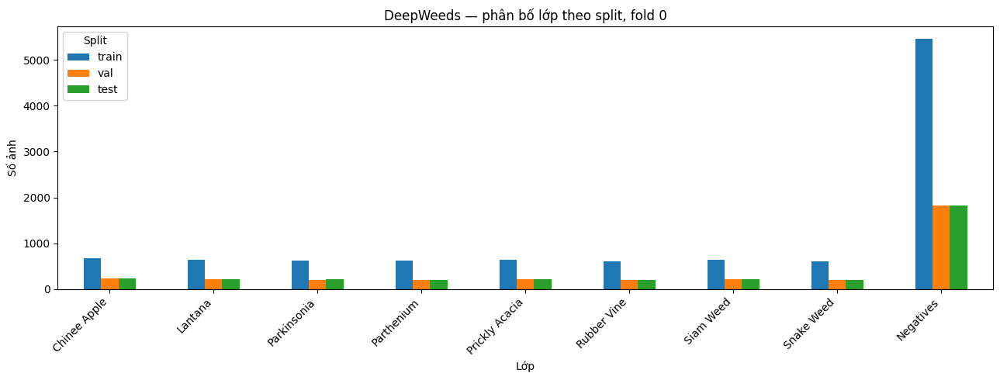

,Class,total,reference,difference
Label,,,,
0,Chinee Apple,1126,1125,1
1,Lantana,1063,1064,-1
2,Parkinsonia,1031,1031,0
3,Parthenium,1022,1022,0
4,Prickly Acacia,1062,1062,0
5,Rubber Vine,1009,1009,0
6,Siam Weed,1074,1074,0
7,Snake Weed,1016,1016,0
8,Negatives,9106,9106,0


Tỷ lệ lớp lớn nhất / nhỏ nhất: 9.02
Tỷ lệ Negatives: 52.01%


In [10]:
import matplotlib.pyplot as plt

plot_counts = class_counts.set_index("Class")[["train", "val", "test"]]

ax = plot_counts.plot(
    kind="bar",
    figsize=(13, 5),
)

ax.set_title("DeepWeeds — phân bố lớp theo split, fold 0")
ax.set_xlabel("Lớp")
ax.set_ylabel("Số ảnh")
ax.legend(title="Split")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    WORK_DIR / "curves" / "EDA_class_distribution.png",
    dpi=160,
)

plt.show()

# Số tham khảo trong README của repo.
reference_counts = np.array([
    1125, 1064, 1031, 1022, 1062,
    1009, 1074, 1016, 9106,
])

comparison = class_counts[["Class", "total"]].copy()
comparison["reference"] = reference_counts
comparison["difference"] = (
    comparison["total"] - comparison["reference"]
)

display(comparison)

largest = class_counts["total"].max()
smallest = class_counts["total"].min()

print(f"Tỷ lệ lớp lớn nhất / nhỏ nhất: {largest / smallest:.2f}")
print(
    "Tỷ lệ Negatives:",
    f"{class_counts.loc[8, 'total'] / 17509:.2%}",
)

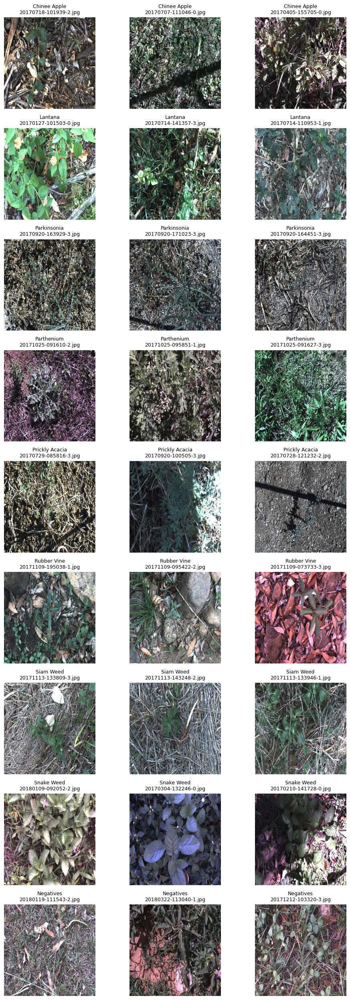

In [11]:
from PIL import Image

fig, axes = plt.subplots(
    nrows=9,
    ncols=3,
    figsize=(10, 25),
)

for label in range(9):
    samples = (
        train_df[train_df["Label"] == label]
        .sample(n=3, random_state=0)
    )

    for column, filename in enumerate(samples["Filename"]):
        ax = axes[label, column]

        with Image.open(IMAGES_DIR / filename) as image:
            ax.imshow(image.convert("RGB"))

        ax.set_title(
            f"{dataset.CLASS_NAMES[label]}\n{filename}",
            fontsize=9,
        )
        ax.axis("off")

plt.tight_layout()

plt.savefig(
    WORK_DIR / "curves" / "EDA_samples.png",
    dpi=150,
)

plt.show()

In [12]:
from collections import Counter

size_counts = Counter()
mode_counts = Counter()

for filename in train_df["Filename"]:
    with Image.open(IMAGES_DIR / filename) as image:
        size_counts[image.size] += 1
        mode_counts[image.mode] += 1

print("Kích thước ảnh trong train:")
print(dict(size_counts))

print("\nChế độ màu:")
print(dict(mode_counts))

image_stats = {
    "sizes": {
        f"{width}x{height}": count
        for (width, height), count in size_counts.items()
    },
    "modes": dict(mode_counts),
}

with open(WORK_DIR / "image_stats.json", "w") as f:
    json.dump(image_stats, f, indent=2)

Kích thước ảnh trong train:
{(256, 256): 10501}

Chế độ màu:
{'RGB': 10501}


In [13]:
import random
import numpy as np
import torch

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

SEED = 0
set_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Seed:", SEED)
print("Device:", device)
print("Thư mục bài làm:", WORK_DIR)

assert device.type == "cuda", "Bật GPU trước khi tiếp tục."

Seed: 0
Device: cuda
Thư mục bài làm: /content/drive/MyDrive/2A202602800_NguyenVanHong


In [14]:
import importlib
import dataset
import timm

importlib.reload(dataset)

set_seed(SEED)

tiny_df = (
    train_df.groupby("Label", group_keys=False)
    .sample(n=1, random_state=SEED)
    .sort_values("Label")
    .reset_index(drop=True)
)

tiny_loader = dataset.make_loader(
    df=tiny_df,
    images_dir=IMAGES_DIR,
    transform=dataset.build_transforms(
        train=False,
        img_size=224,
    ),
    batch_size=9,
    train=False,
    num_workers=0,
)

images, labels, filenames = next(iter(tiny_loader))

print("Shape ảnh:", images.shape)
print("Nhãn:", labels.tolist())
print("Tên ảnh:", list(filenames))

assert images.shape == (9, 3, 224, 224)
assert labels.tolist() == list(range(9))
assert torch.isfinite(images).all()

images = images.to(device)
labels = labels.to(device)

Shape ảnh: torch.Size([9, 3, 224, 224])
Nhãn: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tên ảnh: ['20170718-101939-2.jpg', '20170721-115458-1.jpg', '20171102-123413-2.jpg', '20170913-101846-1.jpg', '20171102-095402-2.jpg', '20171109-095536-2.jpg', '20171113-131054-1.jpg', '20170704-150938-0.jpg', '20180322-130809-1.jpg']


In [15]:
set_seed(SEED)

check_model = timm.create_model(
    "resnet18",
    pretrained=True,
    num_classes=9,
).to(device)

criterion = torch.nn.CrossEntropyLoss()

check_model.eval()

with torch.inference_mode():
    initial_logits = check_model(images)
    initial_loss = criterion(initial_logits, labels).item()

reference_loss = float(np.log(9))

print("Shape đầu ra:", initial_logits.shape)
print(f"Loss ban đầu: {initial_loss:.4f}")
print(f"Mốc tham khảo ln(9): {reference_loss:.4f}")

assert initial_logits.shape == (9, 9)
assert torch.isfinite(initial_logits).all()
assert np.isfinite(initial_loss)

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Shape đầu ra: torch.Size([9, 9])
Loss ban đầu: 2.1949
Mốc tham khảo ln(9): 2.1972


In [16]:
optimizer = torch.optim.Adam(
    check_model.parameters(),
    lr=1e-3,
    weight_decay=0,
)

overfit_history = []

for step in range(300):
    check_model.eval()

    optimizer.zero_grad(set_to_none=True)

    logits = check_model(images)
    loss = criterion(logits, labels)

    assert torch.isfinite(loss), "Loss không hữu hạn."

    loss.backward()
    optimizer.step()

    # Đo lại sau bước cập nhật.
    with torch.inference_mode():
        updated_logits = check_model(images)
        updated_loss = criterion(updated_logits, labels).item()
        accuracy = (
            updated_logits.argmax(dim=1) == labels
        ).float().mean().item()

    overfit_history.append({
        "step": step + 1,
        "loss": updated_loss,
        "accuracy": accuracy,
    })

    if step == 0 or (step + 1) % 25 == 0:
        print(
            f"Step {step + 1:3d} | "
            f"loss={updated_loss:.5f} | "
            f"accuracy={accuracy:.2%}"
        )

    if updated_loss < 0.01 and accuracy == 1.0:
        break

print("\nKết quả cuối:")
print(f"Loss: {updated_loss:.6f}")
print(f"Accuracy: {accuracy:.2%}")

assert updated_loss < 0.05 and accuracy == 1.0, (
    "Chưa overfit được batch nhỏ. "
    "Dừng để kiểm tra trước khi chạy thí nghiệm thật."
)

Step   1 | loss=1.98693 | accuracy=66.67%

Kết quả cuối:
Loss: 0.004214
Accuracy: 100.00%


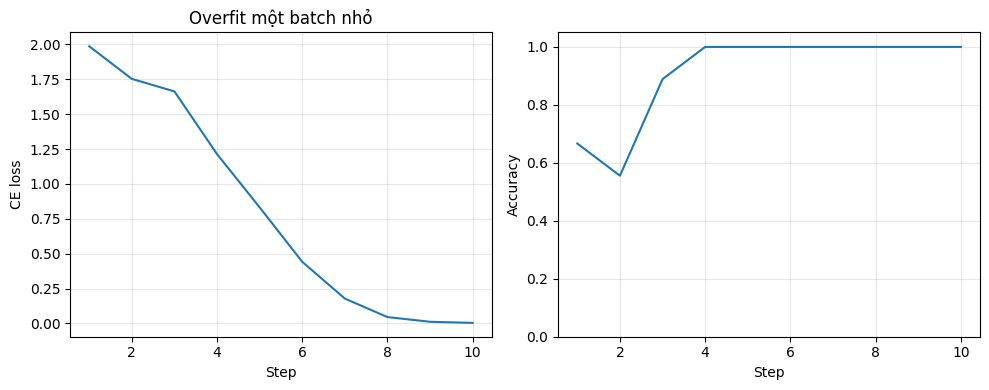

In [17]:
import matplotlib.pyplot as plt

overfit_df = pd.DataFrame(overfit_history)
overfit_df.to_csv(
    WORK_DIR / "pipeline_overfit_history.csv",
    index=False,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(overfit_df["step"], overfit_df["loss"])
axes[0].set_xlabel("Step")
axes[0].set_ylabel("CE loss")
axes[0].set_title("Overfit một batch nhỏ")

axes[1].plot(overfit_df["step"], overfit_df["accuracy"])
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    WORK_DIR / "curves" / "pipeline_overfit.png",
    dpi=160,
)
plt.show()

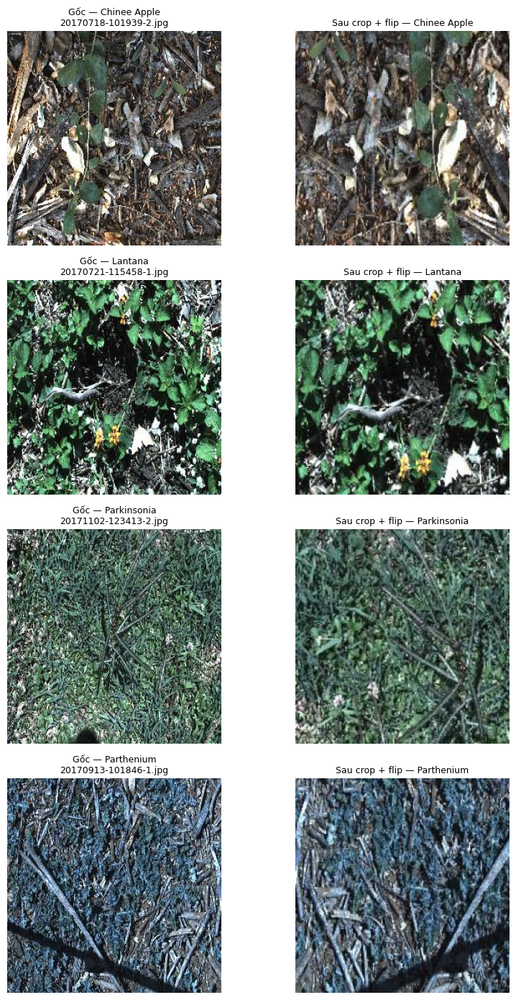

In [18]:
set_seed(SEED)

aug_dataset = dataset.DeepWeedsDataset(
    df=tiny_df,
    images_dir=IMAGES_DIR,
    transform=dataset.build_transforms(
        train=True,
        img_size=224,
        aug="basic",
    ),
)

mean = torch.tensor(dataset.IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(dataset.IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(4, 2, figsize=(9, 14))

for row in range(4):
    augmented, label, filename = aug_dataset[row]

    # Khôi phục về khoảng màu để hiển thị.
    restored = (augmented * std + mean).clamp(0, 1)

    with Image.open(IMAGES_DIR / filename) as original:
        axes[row, 0].imshow(original.convert("RGB"))

    axes[row, 1].imshow(restored.permute(1, 2, 0))

    class_name = dataset.CLASS_NAMES[label]

    axes[row, 0].set_title(
        f"Gốc — {class_name}\n{filename}",
        fontsize=9,
    )
    axes[row, 1].set_title(
        f"Sau crop + flip — {class_name}",
        fontsize=9,
    )

    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig(
    WORK_DIR / "curves" / "pipeline_augmentation.png",
    dpi=160,
)
plt.show()

In [19]:
import json

pipeline_check = {
    "seed": SEED,
    "model": "resnet18 pretrained, new 9-class head",
    "initial_ce": initial_loss,
    "uniform_ce_reference": reference_loss,
    "overfit_final_ce": updated_loss,
    "overfit_accuracy": accuracy,
    "overfit_steps": len(overfit_history),
    "augmentation": "RandomResizedCrop(224) + HorizontalFlip",
}

with open(WORK_DIR / "pipeline_check.json", "w") as f:
    json.dump(pipeline_check, f, indent=2)

del check_model, optimizer, images, labels
torch.cuda.empty_cache()

print("Đã lưu kết quả kiểm tra pipeline.")

Đã lưu kết quả kiểm tra pipeline.


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [20]:
import os
from pathlib import Path

WORK_DIR = Path(
    "/content/drive/MyDrive/2A202602800_NguyenVanHong"
)
CODE_DIR = WORK_DIR / "code"

assert CODE_DIR.is_dir()
assert (CODE_DIR / "dataset.py").is_file()

os.chdir(CODE_DIR)

print("Các cell %%writefile sẽ ghi vào:", Path.cwd())

Các cell %%writefile sẽ ghi vào: /content/drive/MyDrive/2A202602800_NguyenVanHong/code


In [ ]:
%%writefile model.py
import copy

import torch
import timm


def build_model(
    name,
    pretrained=True,
    num_classes=9,
    drop_rate=0.0,
    init="finetune",
):
    if init not in ["scratch", "frozen", "finetune"]:
        raise ValueError(f"Init không hỗ trợ: {init}")

    model = timm.create_model(
        name,
        pretrained=pretrained and init != "scratch",
        num_classes=num_classes,
        drop_rate=drop_rate,
    )

    if init == "frozen":
        freeze_backbone(model)

    return model


def freeze_backbone(model):
    # Đóng băng toàn bộ, sau đó mở lại head.
    model.requires_grad_(False)
    model.get_classifier().requires_grad_(True)
    model.eval()


def param_groups(
    model,
    lr_backbone,
    lr_head,
    weight_decay,
):
    head_ids = {
        id(parameter)
        for parameter in model.get_classifier().parameters()
    }

    groups = {}

    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue

        learning_rate = (
            lr_head if id(parameter) in head_ids else lr_backbone
        )

        # Bias và tham số norm không nhận weight decay.
        decay = (
            0.0
            if parameter.ndim <= 1 or name.endswith(".bias")
            else weight_decay
        )

        key = (learning_rate, decay)
        groups.setdefault(key, []).append(parameter)

    return [
        {
            "params": parameters,
            "lr": learning_rate,
            "weight_decay": decay,
        }
        for (learning_rate, decay), parameters in groups.items()
    ]


def count_params(model):
    # Đếm cả tham số bị đóng băng, đơn vị triệu.
    return sum(p.numel() for p in model.parameters()) / 1e6


def count_gmacs(model, img_size=224):
    from fvcore.nn import FlopCountAnalysis

    cpu_model = copy.deepcopy(model).cpu().float().eval()
    sample = torch.zeros(1, 3, img_size, img_size)

    analysis = FlopCountAnalysis(cpu_model, sample)
    gmac = analysis.total() / 1e9

    unsupported = {
        str(operation): int(count)
        for operation, count in analysis.unsupported_ops().items()
    }

    if unsupported:
        print("Lưu ý GMAC: toán tử chưa được fvcore tính:", unsupported)

    return float(gmac)


In [ ]:
%%writefile losses.py
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F


class LabelSmoothingCE(nn.CrossEntropyLoss):
    def __init__(self, smoothing=0.1):
        super().__init__(label_smoothing=smoothing)


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma

        self.register_buffer(
            "alpha",
            None if alpha is None
            else torch.tensor(alpha, dtype=torch.float32),
        )

    def forward(self, logits, target):
        log_prob = F.log_softmax(logits, dim=1)

        log_pt = log_prob.gather(
            1, target.unsqueeze(1)
        ).squeeze(1)

        pt = log_pt.exp()
        loss = -((1 - pt) ** self.gamma) * log_pt

        if self.alpha is not None:
            loss = loss * self.alpha[target]

        return loss.mean()


def build_criterion(kind="ce", **kwargs):
    if kind == "ce":
        return nn.CrossEntropyLoss()

    if kind == "ls":
        return LabelSmoothingCE(
            kwargs.get("smoothing", 0.1)
        )

    if kind == "focal":
        return FocalLoss(
            gamma=kwargs.get("gamma", 2.0),
            alpha=kwargs.get("alpha"),
        )

    if kind == "ce_weighted":
        return nn.CrossEntropyLoss(
            weight=kwargs["weight"]
        )

    raise ValueError(f"Loss không hỗ trợ: {kind}")


def class_weights(counts, beta=0.0):
    counts = torch.tensor(
        np.array(counts, copy=True),
        dtype=torch.float32,
    )

    if (counts <= 0).any():
        raise ValueError("Mỗi lớp train phải có ít nhất một ảnh")

    if not 0 <= beta < 1:
        raise ValueError("beta phải thuộc [0, 1)")

    if beta == 0:
        weights = 1.0 / counts
    else:
        weights = (1 - beta) / (1 - beta ** counts)

    return weights / weights.mean()


def mix_batch(x, y, alpha=1.0, mode="cutmix"):
    if alpha <= 0:
        raise ValueError("alpha phải > 0")

    lam = float(np.random.beta(alpha, alpha))
    permutation = torch.randperm(
        x.size(0), device=x.device
    )

    if mode == "mixup":
        mixed = lam * x + (1 - lam) * x[permutation]

    elif mode == "cutmix":
        height, width = x.shape[-2:]
        ratio = np.sqrt(1 - lam)

        box_height = int(height * ratio)
        box_width = int(width * ratio)

        center_y = np.random.randint(height)
        center_x = np.random.randint(width)

        y1 = max(0, center_y - box_height // 2)
        y2 = min(height, center_y + (box_height + 1) // 2)
        x1 = max(0, center_x - box_width // 2)
        x2 = min(width, center_x + (box_width + 1) // 2)

        mixed = x.clone()
        mixed[:, :, y1:y2, x1:x2] = (
            x[permutation, :, y1:y2, x1:x2]
        )

        lam = 1 - (
            (y2 - y1) * (x2 - x1)
            / (height * width)
        )

    else:
        raise ValueError(f"Mix không hỗ trợ: {mode}")

    return mixed, (y, y[permutation], lam)


def mixed_loss(criterion, logits, targets):
    y_a, y_b, lam = targets

    return (
        lam * criterion(logits, y_a)
        + (1 - lam) * criterion(logits, y_b)
    )


In [ ]:
%%writefile train.py
from dataclasses import dataclass, asdict
from pathlib import Path

import json
import random
import time
import platform
import copy

import numpy as np
import pandas as pd
import torch
import timm
import matplotlib.pyplot as plt

import dataset
import model as model_utils
import losses

from eval import compute_metrics, save_predictions


class EMA:
    """Optional helper; not used in the submitted experiments.

    Average parameters, copy buffers (including BN statistics) from the source.
    Evaluate self.model rather than the live training model.
    """
    def __init__(self, model, decay):
        if not 0 <= decay < 1:
            raise ValueError("EMA decay must be in [0, 1)")
        self.decay = decay
        self.model = copy.deepcopy(model).eval().requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        source = dict(model.named_parameters())
        for name, parameter in self.model.named_parameters():
            parameter.lerp_(source[name].detach(), 1 - self.decay)
        source_buffers = dict(model.named_buffers())
        for name, buffer in self.model.named_buffers():
            buffer.copy_(source_buffers[name])

    def copy_to(self, model):
        model.load_state_dict(self.model.state_dict())


@dataclass
class Config:
    exp_id: str = "T00"
    seed: int = 0
    fold: int = 0

    backbone: str = "resnet50"
    init: str = "finetune"
    drop_rate: float = 0.0

    img_size: int = 224
    aug: str = "basic"
    sampler: str | None = None
    mix: str | None = None
    mix_alpha: float = 1.0

    loss: str = "ce"
    label_smoothing: float = 0.0
    focal_gamma: float = 2.0
    class_weight_beta: float | None = None

    epochs: int = 12
    batch_size: int = 32
    lr_backbone: float = 1e-4
    lr_head: float = 1e-3
    weight_decay: float = 0.05
    warmup_epochs: float = 1.0

    amp: bool = True
    num_workers: int = 2

    images_dir: str = "data/images"
    labels_dir: str = "data/labels"
    out_dir: str = "runs"
    pred_dir: str = "predictions"
    curves_dir: str = "curves"

    save_test_predictions: bool = False
    resume: bool = True


def run_dir(cfg):
    return Path(cfg.out_dir) / cfg.exp_id / f"seed{cfg.seed}"


def pred_path(cfg, split):
    return (
        Path(cfg.pred_dir)
        / f"{cfg.exp_id}_seed{cfg.seed}_{split}.csv"
    )


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def softmax_numpy(logits):
    logits = np.asarray(logits, dtype=np.float64)
    logits = logits - logits.max(axis=1, keepdims=True)

    probabilities = np.exp(logits)

    return probabilities / probabilities.sum(
        axis=1, keepdims=True
    )


def build_optimizer(model, cfg):
    return torch.optim.AdamW(
        model_utils.param_groups(
            model,
            cfg.lr_backbone,
            cfg.lr_head,
            cfg.weight_decay,
        )
    )


def build_scheduler(optimizer, cfg, steps_per_epoch):
    warmup_steps = round(
        cfg.warmup_epochs * steps_per_epoch
    )
    total_steps = cfg.epochs * steps_per_epoch

    def lr_multiplier(step):
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)

        progress = (
            (step - warmup_steps)
            / max(1, total_steps - warmup_steps)
        )
        progress = min(1.0, max(0.0, progress))

        return 0.5 * (1 + np.cos(np.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lr_multiplier,
    )


def train_one_epoch(
    model, loader, criterion, optimizer,
    scheduler, scaler, cfg, device,
):
    model.train()

    if cfg.init == "frozen":
        # Backbone/BN ở eval; chỉ head ở train.
        model.eval()
        model.get_classifier().train()

    total_loss = 0.0
    total_samples = 0

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        targets = labels

        if cfg.mix is not None:
            images, targets = losses.mix_batch(
                images,
                labels,
                alpha=cfg.mix_alpha,
                mode=cfg.mix,
            )

        with torch.autocast(
            device_type=device.type,
            enabled=cfg.amp and device.type == "cuda",
        ):
            logits = model(images)

            if cfg.mix is None:
                loss = criterion(logits, labels)
            else:
                loss = losses.mixed_loss(
                    criterion, logits, targets
                )

        if not torch.isfinite(loss):
            raise FloatingPointError("Training loss không hữu hạn")

        scaler.scale(loss).backward()

        old_scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()

        # Không tiến scheduler nếu AMP bỏ qua optimizer step.
        if scaler.get_scale() >= old_scale:
            scheduler.step()

        total_loss += loss.item() * len(labels)
        total_samples += len(labels)

    if total_samples == 0:
        raise ValueError("Không có batch train")

    return {
        "train_loss": total_loss / total_samples,
        "lr": optimizer.param_groups[0]["lr"],
    }


@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()

    filenames = []
    all_labels = []
    all_logits = []
    total_loss = 0.0
    total_samples = 0

    for images, labels, names in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images).float()
        loss = criterion(logits, labels)

        filenames.extend(names)
        all_labels.append(labels.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

        total_loss += loss.item() * len(labels)
        total_samples += len(labels)

    return (
        filenames,
        np.concatenate(all_labels),
        np.concatenate(all_logits),
        total_loss / total_samples,
    )


def plot_curves(history, path, title):
    df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(
        df["epoch"], df["train_loss"],
        label="Train objective",
    )
    axes[0].plot(
        df["epoch"], df["val_loss"],
        label="Val CE",
    )
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(
        df["epoch"], df["macro_f1"],
        label="Val macro-F1",
    )
    axes[1].plot(
        df["epoch"], df["top1"],
        label="Val top-1",
    )
    axes[1].set_ylabel("Metric")
    axes[1].legend()

    axes[2].plot(df["epoch"], df["lr"])
    axes[2].set_ylabel("LR — first parameter group")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)

    fig.suptitle(title)
    fig.tight_layout()

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(path, dpi=160)
    plt.close(fig)


def atomic_save(state, path):
    path = Path(path)
    temporary = path.with_suffix(".tmp")

    torch.save(state, temporary)
    temporary.replace(path)


def run(cfg):
    if cfg.save_test_predictions:
        raise ValueError(
            "Bước 1–2 chỉ dùng val. "
            "Phần chạy test sẽ thực hiện riêng ở Bước 4."
        )

    set_seed(cfg.seed)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )
    directory = run_dir(cfg)
    directory.mkdir(parents=True, exist_ok=True)

    config_dict = asdict(cfg)
    config_path = directory / "config.json"

    if config_path.exists():
        previous = json.loads(config_path.read_text())

        if previous != config_dict:
            raise ValueError(
                "exp_id/seed này đã có cấu hình khác. "
                "Dùng exp_id mới nếu thay đổi cấu hình."
            )

    config_path.write_text(
        json.dumps(config_dict, indent=2),
        encoding="utf-8",
    )

    train_df, val_df, test_df = dataset.load_split(
        cfg.labels_dir, cfg.fold
    )

    dataset.check_split(
        train_df, val_df, test_df, cfg.images_dir
    )

    model = model_utils.build_model(
        cfg.backbone,
        init=cfg.init,
        drop_rate=cfg.drop_rate,
    ).to(device)

    pretrained_cfg = model.pretrained_cfg

    mean = pretrained_cfg.get(
        "mean", dataset.IMAGENET_MEAN
    )
    std = pretrained_cfg.get(
        "std", dataset.IMAGENET_STD
    )

    train_loader = dataset.make_loader(
        train_df,
        cfg.images_dir,
        dataset.build_transforms(
            True, cfg.img_size, cfg.aug, mean, std
        ),
        cfg.batch_size,
        True,
        sampler=cfg.sampler,
        num_workers=cfg.num_workers,
    )

    val_loader = dataset.make_loader(
        val_df,
        cfg.images_dir,
        dataset.build_transforms(
            False, cfg.img_size, mean=mean, std=std
        ),
        cfg.batch_size,
        False,
        num_workers=cfg.num_workers,
    )

    counts = (
        train_df["Label"].value_counts()
        .reindex(range(9), fill_value=0)
        .to_numpy()
    )

    weights = losses.class_weights(
        counts,
        beta=cfg.class_weight_beta or 0.0,
    )

    criterion = losses.build_criterion(
        cfg.loss,
        smoothing=cfg.label_smoothing,
        gamma=cfg.focal_gamma,
        weight=weights,
    ).to(device)

    # Val loss luôn dùng CE không trọng số.
    val_criterion = torch.nn.CrossEntropyLoss().to(device)

    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(
        optimizer, cfg, len(train_loader)
    )
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=cfg.amp and device.type == "cuda",
    )

    history = []
    best_f1 = -1.0
    best_epoch = 0
    start_epoch = 0

    last_path = directory / "last.pt"

    if cfg.resume and last_path.exists():
        state = torch.load(
            last_path,
            map_location=device,
            weights_only=False,
        )

        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])

        history = state["history"]
        best_f1 = state["best_f1"]
        best_epoch = state["best_epoch"]
        start_epoch = state["epoch"]

        random.setstate(state["python_rng"])
        np.random.set_state(state["numpy_rng"])
        torch.set_rng_state(state["torch_rng"].cpu())

        if device.type == "cuda" and state["cuda_rng"] is not None:
            torch.cuda.set_rng_state_all(
                [s.cpu() for s in state["cuda_rng"]]
            )

        print(f"Resume từ epoch {start_epoch}")

    environment = {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "timm": timm.__version__,
        "gpu": (
            torch.cuda.get_device_name(0)
            if device.type == "cuda" else "CPU"
        ),
        "pretrained_cfg": pretrained_cfg,
        "preprocessing": {
            "train": "RandomResizedCrop + HorizontalFlip",
            "val": "Resize(size*256/224) + CenterCrop",
            "interpolation": "torchvision default bilinear",
            "mean": mean,
            "std": std,
        },
    }

    (directory / "environment.json").write_text(
        json.dumps(environment, indent=2, default=str),
        encoding="utf-8",
    )

    for epoch in range(start_epoch, cfg.epochs):
        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        row = train_one_epoch(
            model, train_loader, criterion,
            optimizer, scheduler, scaler, cfg, device,
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        train_seconds = time.perf_counter() - start_time

        names, y_true, logits, val_loss = evaluate(
            model, val_loader, val_criterion, device
        )

        probabilities = softmax_numpy(logits)
        metrics = compute_metrics(
            y_true,
            probabilities.argmax(axis=1),
            probabilities,
        )

        row.update({
            "epoch": epoch + 1,
            "val_loss": float(val_loss),
            "macro_f1": float(metrics["macro_f1"]),
            "top1": float(metrics["top1"]),
            "train_seconds": float(train_seconds),
        })

        history.append(row)

        # Chỉ dùng > để hòa thì giữ epoch sớm hơn.
        if row["macro_f1"] > best_f1:
            best_f1 = row["macro_f1"]
            best_epoch = epoch + 1

            atomic_save(
                {
                    "model": model.state_dict(),
                    "epoch": best_epoch,
                    "macro_f1": best_f1,
                },
                directory / "best.pt",
            )

        atomic_save(
            {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "epoch": epoch + 1,
                "history": history,
                "best_f1": best_f1,
                "best_epoch": best_epoch,
                "python_rng": random.getstate(),
                "numpy_rng": np.random.get_state(),
                "torch_rng": torch.get_rng_state(),
                "cuda_rng": (
                    torch.cuda.get_rng_state_all()
                    if device.type == "cuda" else None
                ),
            },
            last_path,
        )

        pd.DataFrame(history).to_csv(
            directory / "history.csv",
            index=False,
        )

        plot_curves(
            history,
            Path(cfg.curves_dir)
            / f"{cfg.exp_id}_seed{cfg.seed}.png",
            f"{cfg.exp_id} | {cfg.backbone} | seed {cfg.seed}",
        )

        print(
            f"{cfg.exp_id} | epoch {epoch + 1}/{cfg.epochs} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"macro-F1={row['macro_f1']:.4f} | "
            f"top1={row['top1']:.4f} | "
            f"train={train_seconds:.1f}s",
            flush=True,
        )

    best_state = torch.load(
        directory / "best.pt",
        map_location=device,
        weights_only=False,
    )
    model.load_state_dict(best_state["model"])

    names, y_true, logits, _ = evaluate(
        model, val_loader, val_criterion, device
    )

    probabilities = softmax_numpy(logits)
    metrics = compute_metrics(
        y_true, probabilities.argmax(axis=1), probabilities
    )

    np.savez_compressed(
        directory / "val_logits.npz",
        filenames=np.asarray(names),
        y_true=y_true,
        logits=logits,
    )

    Path(cfg.pred_dir).mkdir(parents=True, exist_ok=True)

    save_predictions(
        pred_path(cfg, "val"),
        names,
        y_true,
        probabilities,
    )

    summary = {
        "exp_id": cfg.exp_id,
        "backbone": cfg.backbone,
        "tag": pretrained_cfg.get("tag", ""),
        "seed": cfg.seed,
        "epochs": cfg.epochs,
        "batch_size": cfg.batch_size,
        "img_size": cfg.img_size,
        "best_epoch": best_epoch,
        "macro_f1_val": float(metrics["macro_f1"]),
        "top1_val": float(metrics["top1"]),
        "params_M": model_utils.count_params(model),
        "gmac": model_utils.count_gmacs(
            model, cfg.img_size
        ),
        "train_seconds_per_epoch": float(
            np.mean([r["train_seconds"] for r in history])
        ),
        "gmac_tool": "fvcore; 1 multiply-add = 1",
    }

    (directory / "summary.json").write_text(
        json.dumps(summary, indent=2),
        encoding="utf-8",
    )

    return summary


def parse_overrides(pairs):
    """Parse CLI overrides without silently accepting invalid fields/types."""
    defaults = asdict(Config())
    optional_numeric = {"class_weight_beta"}
    optional_strings = {"sampler", "mix"}
    result = {}
    for pair in pairs:
        if "=" not in pair:
            raise ValueError(f"Expected KEY=VALUE: {pair}")
        key, value = pair.split("=", 1)
        if key not in defaults:
            raise ValueError(f"Unknown Config field: {key}")
        default = defaults[key]
        if key in optional_numeric | optional_strings:
            parsed = None if value.lower() == "none" else (
                float(value) if key in optional_numeric else value
            )
        elif isinstance(default, bool):
            if value.lower() not in {"true", "false"}:
                raise ValueError(f"{key}: expected true or false")
            parsed = value.lower() == "true"
        else:
            parsed = type(default)(value)
        result[key] = parsed
    return result


def main():
    import argparse
    parser = argparse.ArgumentParser(description="Train one validation-selected experiment")
    parser.add_argument("--set", nargs="*", default=[])
    cfg = Config(**parse_overrides(parser.parse_args().set))
    print(json.dumps(run(cfg), indent=2))


if __name__ == "__main__":
    main()


In [24]:
import sys
import importlib

sys.path.insert(0, str(REPO_DIR))
sys.path.insert(0, str(CODE_DIR))

import dataset
import model
import losses
import train

for module in [dataset, model, losses, train]:
    importlib.reload(module)
    print(module.__name__, "→", module.__file__)

from train import Config, run

# Kiểm tra các loss dễ sai trước khi dùng ở Bước 2.
z = torch.randn(12, 9)
y = torch.randint(0, 9, (12,))

ce = torch.nn.functional.cross_entropy(z, y)

assert torch.allclose(
    losses.FocalLoss(gamma=0)(z, y),
    ce,
    atol=1e-6,
)

assert torch.allclose(
    losses.LabelSmoothingCE(smoothing=0)(z, y),
    ce,
    atol=1e-6,
)

print("Import và kiểm tra loss: OK")

dataset → /content/drive/MyDrive/2A202602800_NguyenVanHong/code/dataset.py
model → /content/drive/MyDrive/2A202602800_NguyenVanHong/code/model.py
losses → /content/drive/MyDrive/2A202602800_NguyenVanHong/code/losses.py
train → /content/drive/MyDrive/2A202602800_NguyenVanHong/code/train.py
Import và kiểm tra loss: OK


In [25]:
COMMON = {
    "images_dir": str(IMAGES_DIR),
    "labels_dir": str(LABELS_DIR),
    "out_dir": str(WORK_DIR / "runs"),
    "pred_dir": str(WORK_DIR / "predictions"),
    "curves_dir": str(WORK_DIR / "curves"),

    "epochs": 12,
    "batch_size": 32,
    "img_size": 224,
    "num_workers": 2,

    "init": "finetune",
    "aug": "basic",
    "loss": "ce",

    "lr_backbone": 1e-4,
    "lr_head": 1e-3,
    "weight_decay": 0.05,
    "warmup_epochs": 1.0,

    "amp": True,
    "save_test_predictions": False,
}

BACKBONES = [
    ("B01", "resnet50"),
    ("B02", "resnext50_32x4d"),
    ("B03", "convnext_tiny"),
    ("B04", "deit_small_patch16_224"),
    ("B05", "mobilenetv3_large_100"),
]

print("GPU:", torch.cuda.get_device_name(0))
print("Batch:", COMMON["batch_size"])
print("Epoch:", COMMON["epochs"])

GPU: Tesla T4
Batch: 32
Epoch: 12


In [26]:
import gc

for exp_id, backbone in BACKBONES:
    probe_model = None
    probe_optimizer = None
    x = None
    logits = None
    loss = None

    try:
        probe_model = model.build_model(
            backbone,
            pretrained=False,
        ).cuda().train()

        probe_optimizer = train.build_optimizer(
            probe_model,
            Config(backbone=backbone, **COMMON),
        )

        x = torch.randn(
            COMMON["batch_size"], 3, 224, 224,
            device="cuda",
        )
        y = torch.randint(
            0, 9, (COMMON["batch_size"],),
            device="cuda",
        )

        with torch.autocast("cuda"):
            logits = probe_model(x)
            loss = torch.nn.functional.cross_entropy(logits, y)

        loss.backward()
        probe_optimizer.step()
        torch.cuda.synchronize()

        print(exp_id, backbone, "→ batch OK")

    finally:
        del probe_model, probe_optimizer, x, logits, loss
        gc.collect()
        torch.cuda.empty_cache()

B01 resnet50 → batch OK
B02 resnext50_32x4d → batch OK
B03 convnext_tiny → batch OK
B04 deit_small_patch16_224 → batch OK
B05 mobilenetv3_large_100 → batch OK


In [27]:
import gc

backbone_results = []

for exp_id, backbone in BACKBONES:
    print("\n" + "=" * 60)
    print("Bắt đầu:", exp_id, backbone)

    cfg = Config(
        exp_id=exp_id,
        backbone=backbone,
        seed=0,
        **COMMON,
    )

    result = run(cfg)
    backbone_results.append(result)

    # Lưu bảng sau mỗi model để tránh mất kết quả.
    pd.DataFrame(backbone_results).to_csv(
        WORK_DIR / "backbone_results.csv",
        index=False,
    )

    gc.collect()
    torch.cuda.empty_cache()

backbone_df = pd.DataFrame(backbone_results)

display(
    backbone_df.sort_values(
        "macro_f1_val",
        ascending=False,
    )
)


Bắt đầu: B01 resnet50
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

B01 | epoch 1/12 | train_loss=1.5553 | val_loss=1.1092 | macro-F1=0.3409 | top1=0.6198 | train=67.0s
B01 | epoch 2/12 | train_loss=0.8702 | val_loss=0.7007 | macro-F1=0.6636 | top1=0.7561 | train=53.7s
B01 | epoch 3/12 | train_loss=0.6362 | val_loss=0.5588 | macro-F1=0.7377 | top1=0.8083 | train=62.8s
B01 | epoch 4/12 | train_loss=0.5370 | val_loss=0.4719 | macro-F1=0.7868 | top1=0.8389 | train=61.7s
B01 | epoch 5/12 | train_loss=0.4781 | val_loss=0.4712 | macro-F1=0.7856 | top1=0.8406 | train=60.1s
B01 | epoch 6/12 | train_loss=0.4313 | val_loss=0.4137 | macro-F1=0.8048 | top1=0.8546 | train=57.4s
B01 | epoch 7/12 | train_loss=0.3952 | val_loss=0.4035 | macro-F1=0.8158 | top1=0.8635 | train=60.8s
B01 | epoch 8/12 | train_loss=0.3819 | val_loss=0.4194 | macro-F1=0.8059 | top1=0.8563 | train=59.9s
B01 | epoch 9/12 | train_loss=0.3762 | val_loss=0.3792 | macro-F1=0.8268 | top1=0.8726 | train=57.0s
B01 | epoch 10/12 | train_loss=0.3654 | val_loss=0.3971 | macro-F1=0.8161 | top1=0.8649 | t

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::max_pool2d': 1, 'aten::add_': 16}

Bắt đầu: B02 resnext50_32x4d
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.


...

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.1MB            

model.safetensors: downloading bytes:           |  0.00B            

B05 | epoch 1/12 | train_loss=1.6965 | val_loss=1.4012 | macro-F1=0.3791 | top1=0.5556 | train=48.3s
B05 | epoch 2/12 | train_loss=0.7320 | val_loss=1.2953 | macro-F1=0.4508 | top1=0.5790 | train=47.0s
B05 | epoch 3/12 | train_loss=0.4988 | val_loss=1.1112 | macro-F1=0.5007 | top1=0.6532 | train=49.1s
B05 | epoch 4/12 | train_loss=0.4020 | val_loss=0.8464 | macro-F1=0.6087 | top1=0.7295 | train=49.0s
B05 | epoch 5/12 | train_loss=0.3240 | val_loss=0.7555 | macro-F1=0.6380 | top1=0.7395 | train=49.3s
B05 | epoch 6/12 | train_loss=0.2849 | val_loss=0.6234 | macro-F1=0.7192 | top1=0.7912 | train=49.7s
B05 | epoch 7/12 | train_loss=0.2511 | val_loss=0.5876 | macro-F1=0.7425 | top1=0.8069 | train=49.2s
B05 | epoch 8/12 | train_loss=0.2283 | val_loss=0.5688 | macro-F1=0.7452 | top1=0.8118 | train=49.5s
B05 | epoch 9/12 | train_loss=0.2095 | val_loss=0.6007 | macro-F1=0.7209 | top1=0.7972 | train=49.0s
B05 | epoch 10/12 | train_loss=0.1951 | val_loss=0.5708 | macro-F1=0.7415 | top1=0.8061 | t

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::hardswish_': 21, 'aten::add': 10, 'aten::mean': 8, 'aten::hardsigmoid': 8, 'aten::mul': 8}


,exp_id,backbone,tag,seed,epochs,batch_size,img_size,best_epoch,macro_f1_val,top1_val,params_M,gmac,train_seconds_per_epoch,gmac_tool
2,B03,convnext_tiny,in12k_ft_in1k,0,12,32,224,10,0.968728,0.976292,27.827049,4.469676,69.629379,fvcore; 1 multiply-add = 1
3,B04,deit_small_patch16_224,fb_in1k,0,12,32,224,12,0.947138,0.962296,21.669129,4.250294,54.560457,fvcore; 1 multiply-add = 1
0,B01,resnet50,a1_in1k,0,12,32,224,9,0.826840,0.872608,23.526473,4.109483,59.714270,fvcore; 1 multiply-add = 1
4,B05,mobilenetv3_large_100,ra_in1k,0,12,32,224,12,0.766247,0.824050,4.213561,0.224168,48.871699,fvcore; 1 multiply-add = 1
1,B02,resnext50_32x4d,a1h_in1k,0,12,32,224,12,0.765552,0.820051,22.998345,4.257352,65.077362,fvcore; 1 multiply-add = 1


In [28]:
import json
import time
import gc

@torch.inference_mode()
def measure_forward_latency(model, iterations=50):
    model.eval()
    x = torch.randn(1, 3, 224, 224, device="cuda")

    # Bỏ 10 lần warmup.
    for _ in range(10):
        model(x)

    times_ms = []

    for _ in range(iterations):
        torch.cuda.synchronize()
        start = time.perf_counter()

        model(x)

        torch.cuda.synchronize()

        times_ms.append(
            (time.perf_counter() - start) * 1000
        )

    return {
        "latency_p50_ms": float(np.percentile(times_ms, 50)),
        "latency_p95_ms": float(np.percentile(times_ms, 95)),
        "latency_p99_ms": float(np.percentile(times_ms, 99)),
        "latency_dtype": "FP32",
        "latency_batch": 1,
        "latency_preprocessing": False,
        "gpu": torch.cuda.get_device_name(0),
    }


rows = []

for exp_id, backbone in BACKBONES:
    cfg = Config(
        exp_id=exp_id,
        backbone=backbone,
        seed=0,
        **COMMON,
    )

    directory = train.run_dir(cfg)

    summary = json.loads(
        (directory / "summary.json").read_text()
    )

    measured_model = model.build_model(
        backbone,
        pretrained=False,
    ).cuda()

    state = torch.load(
        directory / "best.pt",
        map_location="cuda",
        weights_only=False,
    )

    measured_model.load_state_dict(state["model"])

    latency = measure_forward_latency(measured_model)
    summary.update(latency)

    (directory / "summary.json").write_text(
        json.dumps(summary, indent=2)
    )

    rows.append(summary)

    del measured_model, state
    gc.collect()
    torch.cuda.empty_cache()

backbone_df = pd.DataFrame(rows).sort_values(
    "macro_f1_val",
    ascending=False,
)

backbone_df.to_csv(
    WORK_DIR / "backbone_results.csv",
    index=False,
)

display(backbone_df[[
    "exp_id",
    "backbone",
    "tag",
    "params_M",
    "gmac",
    "best_epoch",
    "macro_f1_val",
    "top1_val",
    "train_seconds_per_epoch",
    "latency_p50_ms",
    "latency_p95_ms",
]])

,exp_id,backbone,tag,params_M,gmac,best_epoch,macro_f1_val,top1_val,train_seconds_per_epoch,latency_p50_ms,latency_p95_ms
2,B03,convnext_tiny,in12k_ft_in1k,27.827049,4.469676,10,0.968728,0.976292,69.629379,6.330523,10.680635
3,B04,deit_small_patch16_224,fb_in1k,21.669129,4.250294,12,0.947138,0.962296,54.560457,5.311792,9.026484
0,B01,resnet50,a1_in1k,23.526473,4.109483,9,0.826840,0.872608,59.714270,6.578979,10.623503
4,B05,mobilenetv3_large_100,ra_in1k,4.213561,0.224168,12,0.766247,0.824050,48.871699,6.656991,8.524475
1,B02,resnext50_32x4d,a1h_in1k,22.998345,4.257352,12,0.765552,0.820051,65.077362,12.149371,25.015488


### Lựa chọn backbone cho Bước 2

Chọn ConvNeXt-Tiny, macro-F1 val 0.968728, top-1 0.976292.
Theo Backbones hiện tại: p95 FP32 batch1 10.680635 ms;
thời gian train trung bình 67.949494 giây/epoch.
MobileNetV3 có p95 thấp nhất 8.524475 ms nhưng macro-F1 0.766247.
ConvNeXt cân bằng chất lượng và chi phí trong nhóm đã thử.
Val ConvNeXt đạt đỉnh ở epoch10 rồi giảm nhẹ; DeiT tăng tới epoch12.
Một seed và pretrained khác nhau hạn chế kết luận riêng về kiến trúc.


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [29]:
import json
import pandas as pd

backbone_df = pd.read_csv(
    WORK_DIR / "backbone_results.csv"
)

display(
    backbone_df[[
        "exp_id",
        "backbone",
        "macro_f1_val",
        "top1_val",
        "train_seconds_per_epoch",
        "latency_p95_ms",
    ]].sort_values("macro_f1_val", ascending=False)
)

# Thay bằng backbone bạn chọn từ kết quả Bước 1.
SELECTED_BACKBONE = "convnext_tiny"

assert SELECTED_BACKBONE in backbone_df["backbone"].values

print("Backbone dùng cho Bước 2:", SELECTED_BACKBONE)

,exp_id,backbone,macro_f1_val,top1_val,train_seconds_per_epoch,latency_p95_ms
0,B03,convnext_tiny,0.968728,0.976292,69.629379,10.680635
1,B04,deit_small_patch16_224,0.947138,0.962296,54.560457,9.026484
2,B01,resnet50,0.826840,0.872608,59.714270,10.623503
3,B05,mobilenetv3_large_100,0.766247,0.824050,48.871699,8.524475
4,B02,resnext50_32x4d,0.765552,0.820051,65.077362,25.015488


Backbone dùng cho Bước 2: convnext_tiny


### Backbone dùng cho ablation

Chọn ConvNeXt-Tiny, tag in12k_ft_in1k, vì đạt macro-F1 val
cao nhất (0.968728), top-1 val 0.976292 và p95 batch 1
10.680635 ms trong điều kiện đo FP32, không gồm tiền xử lý.

Thời gian train trung bình là 67.95 giây/epoch.
Kết quả sàng lọc dùng một seed. Khác biệt về nguồn pretrained
giữa các backbone hạn chế khả năng kết luận riêng về kiến trúc.

In [30]:
from train import Config, run

# Giữ đúng công thức nền đã dùng ở Bước 1.
BASE_SETTINGS = COMMON.copy()

assert BASE_SETTINGS["save_test_predictions"] is False

EXPERIMENTS = {
    "T00": {
        "axis": "Baseline",
        "description": "Finetune + basic augmentation + CE",
        "changes": {},
    },

    "T01": {
        "axis": "A",
        "description": "Scratch thay cho pretrained finetune",
        "changes": {"init": "scratch"},
    },

    "T02": {
        "axis": "A",
        "description": "Đóng băng backbone, chỉ train head",
        "changes": {"init": "frozen"},
    },

    "T03": {
        "axis": "B",
        "description": "Basic augmentation + CutMix",
        "changes": {
            "mix": "cutmix",
            "mix_alpha": 1.0,
        },
    },

    "T04": {
        "axis": "B",
        "description": "Basic augmentation + Mixup",
        "changes": {
            "mix": "mixup",
            "mix_alpha": 1.0,
        },
    },

    "T05": {
        "axis": "C",
        "description": "CE + label smoothing 0.1",
        "changes": {
            "loss": "ls",
            "label_smoothing": 0.1,
        },
    },

    "T06": {
        "axis": "C",
        "description": "Focal loss, gamma=2",
        "changes": {
            "loss": "focal",
            "focal_gamma": 2.0,
        },
    },

    "T07": {
        "axis": "C",
        "description": "CE với trọng số nghịch tần suất lớp train",
        "changes": {
            "loss": "ce_weighted",
            "class_weight_beta": 0.0,
        },
    },
}


def make_training_config(exp_id, seed=0):
    settings = BASE_SETTINGS.copy()
    settings.update(EXPERIMENTS[exp_id]["changes"])

    return Config(
        exp_id=exp_id,
        backbone=SELECTED_BACKBONE,
        seed=seed,
        **settings,
    )


experiment_plan = pd.DataFrame([
    {
        "exp_id": exp_id,
        "axis": spec["axis"],
        "description": spec["description"],
        "changes": json.dumps(spec["changes"]),
    }
    for exp_id, spec in EXPERIMENTS.items()
])

display(experiment_plan)

experiment_plan.to_csv(
    WORK_DIR / "training_experiment_plan.csv",
    index=False,
)

,exp_id,axis,description,changes
0,T00,Baseline,Finetune + basic augmentation + CE,{}
1,T01,A,Scratch thay cho pretrained finetune,"{""init"": ""scratch""}"
2,T02,A,"Đóng băng backbone, chỉ train head","{""init"": ""frozen""}"
3,T03,B,Basic augmentation + CutMix,"{""mix"": ""cutmix"", ""mix_alpha"": 1.0}"
4,T04,B,Basic augmentation + Mixup,"{""mix"": ""mixup"", ""mix_alpha"": 1.0}"
5,T05,C,CE + label smoothing 0.1,"{""loss"": ""ls"", ""label_smoothing"": 0.1}"
6,T06,C,"Focal loss, gamma=2","{""loss"": ""focal"", ""focal_gamma"": 2.0}"
7,T07,C,CE với trọng số nghịch tần suất lớp train,"{""loss"": ""ce_weighted"", ""class_weight_beta"": 0.0}"


In [31]:
import losses
import torch
import numpy as np

train.set_seed(0)

# Mỗi ảnh có một giá trị riêng để nhận biết vùng bị thay.
x = torch.stack([
    torch.full((3, 32, 32), float(i))
    for i in range(8)
])
y = torch.arange(8)

mixed, (y_a, y_b, lam) = losses.mix_batch(
    x, y, alpha=1.0, mode="cutmix"
)

for i in range(len(y)):
    if y_a[i] != y_b[i]:
        changed_ratio = (
            mixed[i, 0] != x[i, 0]
        ).float().mean().item()

        assert abs(changed_ratio - (1 - lam)) < 1e-6

z = torch.randn(8, 9)
criterion = torch.nn.CrossEntropyLoss()

actual = losses.mixed_loss(
    criterion, z, (y_a, y_b, lam)
)
expected = (
    lam * criterion(z, y_a)
    + (1 - lam) * criterion(z, y_b)
)

assert torch.allclose(actual, expected)

print("CutMix: tỷ lệ vùng thay và mixed loss đều đúng.")
print("Lambda:", lam)

CutMix: tỷ lệ vùng thay và mixed loss đều đúng.
Lambda: 0.4833984375


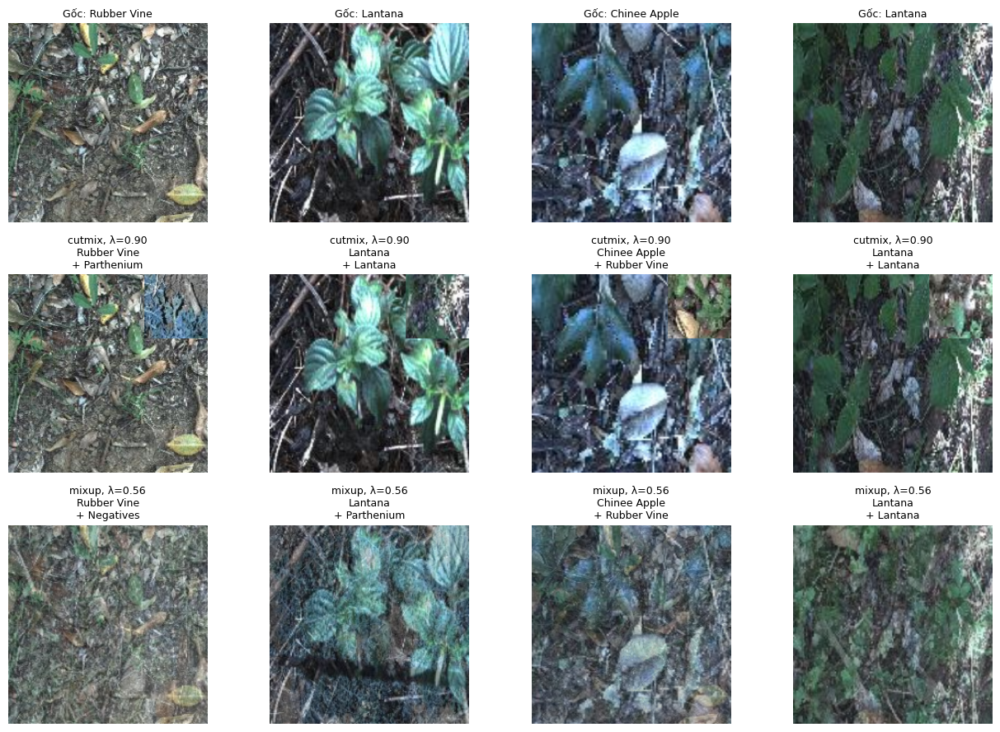

In [32]:
import matplotlib.pyplot as plt

preview_loader = dataset.make_loader(
    train_df,
    IMAGES_DIR,
    dataset.build_transforms(
        train=True,
        img_size=224,
        aug="basic",
    ),
    batch_size=8,
    train=False,
    num_workers=0,
)

x, y, _ = next(iter(preview_loader))

mean = torch.tensor(dataset.IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(dataset.IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(3, 4, figsize=(13, 9))

for column in range(4):
    image = (x[column] * std + mean).clamp(0, 1)
    axes[0, column].imshow(image.permute(1, 2, 0))
    axes[0, column].set_title(
        f"Gốc: {dataset.CLASS_NAMES[y[column].item()]}",
        fontsize=9,
    )
    axes[0, column].axis("off")

for row, mode in enumerate(["cutmix", "mixup"], start=1):
    mixed, (a, b, lam) = losses.mix_batch(
        x, y, alpha=1.0, mode=mode
    )

    for column in range(4):
        image = (mixed[column] * std + mean).clamp(0, 1)

        axes[row, column].imshow(image.permute(1, 2, 0))
        axes[row, column].set_title(
            f"{mode}, λ={lam:.2f}\n"
            f"{dataset.CLASS_NAMES[a[column].item()]}\n"
            f"+ {dataset.CLASS_NAMES[b[column].item()]}",
            fontsize=9,
        )
        axes[row, column].axis("off")

plt.tight_layout()
plt.savefig(
    WORK_DIR / "curves" / "training_mix_preview.png",
    dpi=160,
)
plt.show()

In [33]:
cfg = make_training_config("T00")
print(cfg)

baseline_result = run(cfg)

display(pd.DataFrame([baseline_result]))

Config(exp_id='T00', seed=0, fold=0, backbone='convnext_tiny', init='finetune', drop_rate=0.0, img_size=224, aug='basic', sampler=None, mix=None, mix_alpha=1.0, loss='ce', label_smoothing=0.0, focal_gamma=2.0, class_weight_beta=None, epochs=12, batch_size=32, lr_backbone=0.0001, lr_head=0.001, weight_decay=0.05, warmup_epochs=1.0, amp=True, num_workers=2, images_dir='/content/data', labels_dir='/content/data/labels', out_dir='/content/drive/MyDrive/2A202602800_NguyenVanHong/runs', pred_dir='/content/drive/MyDrive/2A202602800_NguyenVanHong/predictions', curves_dir='/content/drive/MyDrive/2A202602800_NguyenVanHong/curves', save_test_predictions=False, resume=True)
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T00 | epoch 1/12 | train_loss=0.7429 | val_loss=0.4373 | macro-F1=0.8018 | top1=0.8475 | train=64.5s
T00 | epoch 2/12 | train_loss=0.3570 | val_loss=0.1

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}


,exp_id,backbone,tag,seed,epochs,batch_size,img_size,best_epoch,macro_f1_val,top1_val,params_M,gmac,train_seconds_per_epoch,gmac_tool
0,T00,convnext_tiny,in12k_ft_in1k,0,12,32,224,10,0.968728,0.976292,27.827049,4.469676,69.983693,fvcore; 1 multiply-add = 1


In [34]:
import gc

for exp_id in ["T01", "T02", "T03", "T04", "T05", "T06", "T07"]:
    print("\n" + "=" * 60)
    print(exp_id, "—", EXPERIMENTS[exp_id]["description"])

    cfg = make_training_config(exp_id)
    result = run(cfg)

    print(
        f"{exp_id}: "
        f"macro-F1 val={result['macro_f1_val']:.4f}, "
        f"top-1 val={result['top1_val']:.4f}"
    )

    gc.collect()
    torch.cuda.empty_cache()


T01 — Scratch thay cho pretrained finetune
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T01 | epoch 1/12 | train_loss=1.6870 | val_loss=1.6448 | macro-F1=0.0923 | top1=0.5241 | train=67.6s
T01 | epoch 2/12 | train_loss=1.5815 | val_loss=1.6264 | macro-F1=0.1528 | top1=0.4413 | train=67.8s
T01 | epoch 3/12 | train_loss=1.5072 | val_loss=1.4369 | macro-F1=0.1612 | top1=0.5398 | train=71.8s
T01 | epoch 4/12 | train_loss=1.4533 | val_loss=1.4296 | macro-F1=0.2057 | top1=0.5316 | train=70.3s
T01 | epoch 5/12 | train_loss=1.3669 | val_loss=1.3312 | macro-F1=0.1974 | top1=0.5367 | train=78.6s
T01 | epoch 6/12 | train_loss=1.2963 | val_loss=1.2643 | macro-F1=0.3214 | top1=0.5653 | train=69.8s
T01 | epoch 7/12 | train_loss=1.2324 | val_loss=1.3055 | macro-F1=0.2618 | top1=0.5721 | train=72.1s
T01 | epoch 8/12 | train_loss=1.1865 | val_loss=1.2137 | macro-F1=0.3753

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}
T01: macro-F1 val=0.4215, top-1 val=0.6084

T02 — Đóng băng backbone, chỉ train head
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T02 | epoch 1/12 | train_loss=1.1291 | val_loss=0.6168 | macro-F1=0.7380 | top1=0.8003 | train=40.5s
T02 | epoch 2/12 | train_loss=0.5688 | val_loss=0.4846 | macro-F1=0.8026 | top1=0.8435 | train=41.9s
T02 | epoch 3/12 | train_loss=0.4764 | val_loss=0.4489 | macro-F1=0.8067 | top1=0.8512 | train=43.5s
T02 | epoch 4/12 | train_loss=0.4316 | val_loss=0.4073 | macro-F1=0.8283 | top1=0.8660 | train=41.9s
T02 | epoch 5/12 | train_loss=0.4057 | val_loss=0.3894 | macro-F1=0.8395 | top1=0.8735 | train=40.6s
T02 | epoch 6/12 | train_loss=0.3804 | val_loss=0.3771 | macro-F1=0.8428 | top1=0.8740 | train=43.8s
T02 | epoch 7/12 | train_loss=0.3700

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}
T02: macro-F1 val=0.8536, top-1 val=0.8840

T03 — Basic augmentation + CutMix
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T03 | epoch 1/12 | train_loss=1.1744 | val_loss=0.4621 | macro-F1=0.7878 | top1=0.8552 | train=67.0s
T03 | epoch 2/12 | train_loss=0.8220 | val_loss=0.2497 | macro-F1=0.9158 | top1=0.9280 | train=67.7s
T03 | epoch 3/12 | train_loss=0.7295 | val_loss=0.1850 | macro-F1=0.9243 | top1=0.9463 | train=69.9s
T03 | epoch 4/12 | train_loss=0.6542 | val_loss=0.1559 | macro-F1=0.9448 | top1=0.9560 | train=71.1s
T03 | epoch 5/12 | train_loss=0.6371 | val_loss=0.1245 | macro-F1=0.9556 | top1=0.9654 | train=71.9s
T03 | epoch 6/12 | train_loss=0.5970 | val_loss=0.1294 | macro-F1=0.9516 | top1=0.9626 | train=71.1s
T03 | epoch 7/12 | train_loss=0.5428 | val_

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}
T03: macro-F1 val=0.9707, top-1 val=0.9774

T04 — Basic augmentation + Mixup
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T04 | epoch 1/12 | train_loss=1.2289 | val_loss=0.4336 | macro-F1=0.8302 | top1=0.8732 | train=67.2s
T04 | epoch 2/12 | train_loss=0.9555 | val_loss=0.3004 | macro-F1=0.9195 | top1=0.9352 | train=68.0s
T04 | epoch 3/12 | train_loss=0.8836 | val_loss=0.2394 | macro-F1=0.9253 | top1=0.9432 | train=70.7s
T04 | epoch 4/12 | train_loss=0.8407 | val_loss=0.1894 | macro-F1=0.9359 | top1=0.9509 | train=72.6s
T04 | epoch 5/12 | train_loss=0.8008 | val_loss=0.1693 | macro-F1=0.9418 | top1=0.9546 | train=70.3s
T04 | epoch 6/12 | train_loss=0.7523 | val_loss=0.1543 | macro-F1=0.9461 | top1=0.9583 | train=71.4s
T04 | epoch 7/12 | train_loss=0.7290 | val_l

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}
T04: macro-F1 val=0.9656, top-1 val=0.9740

T05 — CE + label smoothing 0.1
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T05 | epoch 1/12 | train_loss=1.0481 | val_loss=0.5180 | macro-F1=0.7896 | top1=0.8489 | train=67.3s
T05 | epoch 2/12 | train_loss=0.7575 | val_loss=0.3202 | macro-F1=0.9108 | top1=0.9263 | train=67.9s
T05 | epoch 3/12 | train_loss=0.6801 | val_loss=0.3057 | macro-F1=0.8930 | top1=0.9206 | train=70.8s
T05 | epoch 4/12 | train_loss=0.6474 | val_loss=0.2602 | macro-F1=0.9268 | top1=0.9403 | train=70.9s
T05 | epoch 5/12 | train_loss=0.6186 | val_loss=0.2015 | macro-F1=0.9508 | top1=0.9600 | train=70.1s
T05 | epoch 6/12 | train_loss=0.5939 | val_loss=0.2138 | macro-F1=0.9421 | top1=0.9543 | train=70.1s
T05 | epoch 7/12 | train_loss=0.5723 | val_los

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}
T05: macro-F1 val=0.9666, top-1 val=0.9746

T06 — Focal loss, gamma=2
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T06 | epoch 1/12 | train_loss=0.4696 | val_loss=0.4092 | macro-F1=0.8408 | top1=0.8820 | train=69.0s
T06 | epoch 2/12 | train_loss=0.1938 | val_loss=0.3732 | macro-F1=0.9009 | top1=0.9180 | train=67.4s
T06 | epoch 3/12 | train_loss=0.1222 | val_loss=0.3004 | macro-F1=0.8914 | top1=0.9109 | train=69.2s
T06 | epoch 4/12 | train_loss=0.1035 | val_loss=0.2143 | macro-F1=0.9349 | top1=0.9486 | train=70.4s
T06 | epoch 5/12 | train_loss=0.0902 | val_loss=0.1843 | macro-F1=0.9457 | top1=0.9560 | train=69.7s
T06 | epoch 6/12 | train_loss=0.0633 | val_loss=0.1506 | macro-F1=0.9492 | top1=0.9586 | train=72.3s
T06 | epoch 7/12 | train_loss=0.0543 | val_loss=0.1

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}
T06: macro-F1 val=0.9697, top-1 val=0.9769

T07 — CE với trọng số nghịch tần suất lớp train
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T07 | epoch 1/12 | train_loss=0.8710 | val_loss=0.7425 | macro-F1=0.7153 | top1=0.7578 | train=66.6s
T07 | epoch 2/12 | train_loss=0.4425 | val_loss=0.7693 | macro-F1=0.7779 | top1=0.7535 | train=67.0s
T07 | epoch 3/12 | train_loss=0.3018 | val_loss=0.3597 | macro-F1=0.8729 | top1=0.8829 | train=72.0s
T07 | epoch 4/12 | train_loss=0.2527 | val_loss=0.3580 | macro-F1=0.8917 | top1=0.8963 | train=69.9s
T07 | epoch 5/12 | train_loss=0.2147 | val_loss=0.2995 | macro-F1=0.8893 | top1=0.9020 | train=72.1s
T07 | epoch 6/12 | train_loss=0.1762 | val_loss=0.3147 | macro-F1=0.8924 | top1=0.9006 | train=69.5s
T07 | epoch 7/12 | train_loss

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}
T07: macro-F1 val=0.9698, top-1 val=0.9771


In [36]:
from eval import compute_metrics

def collect_training_results():
    rows = []

    for exp_id, spec in EXPERIMENTS.items():
        cfg = make_training_config(exp_id)
        directory = train.run_dir(cfg)
        summary_path = directory / "summary.json"

        if not summary_path.exists():
            print("Chưa hoàn thành:", exp_id)
            continue

        summary = json.loads(summary_path.read_text())

        # Tính lại metric từ logit checkpoint tốt nhất.
        saved = np.load(directory / "val_logits.npz")
        probabilities = train.softmax_numpy(saved["logits"])

        metrics = compute_metrics(
            saved["y_true"],
            probabilities.argmax(axis=1),
            probabilities,
        )

        rows.append({
            **summary,
            "axis": spec["axis"],
            "description": spec["description"],
            "changes": json.dumps(spec["changes"]),
            "balanced_acc_val": float(metrics["balanced_acc"]),
            "chinee_apple_f1_val": float(metrics["f1"][0]),
            "snake_weed_f1_val": float(metrics["f1"][7]),
            "negatives_f1_val": float(metrics["f1"][8]),
        })

    results = pd.DataFrame(rows)

    baseline_f1 = results.loc[
        results["exp_id"] == "T00",
        "macro_f1_val",
    ].iloc[0]

    results["delta_vs_T00"] = (
        results["macro_f1_val"] - baseline_f1
    )

    # Đổi từ tỷ lệ sang điểm phần trăm.
    results["delta_percentage_points"] = (
        results["delta_vs_T00"] * 100
    )

    results = results.sort_values(
        "macro_f1_val", ascending=False
    )

    results.to_csv(
        WORK_DIR / "training_results.csv",
        index=False,
    )

    return results


training_df = collect_training_results()

display(training_df[[
    "exp_id",
    "axis",
    "description",
    "best_epoch",
    "macro_f1_val",
    "top1_val",
    "delta_percentage_points",
    "chinee_apple_f1_val",
    "snake_weed_f1_val",
    "negatives_f1_val",
]])

,exp_id,axis,description,best_epoch,macro_f1_val,top1_val,delta_percentage_points,chinee_apple_f1_val,snake_weed_f1_val,negatives_f1_val
3,T03,B,Basic augmentation + CutMix,11,0.970735,0.977435,0.200671,0.934884,0.925301,0.985460
7,T07,C,CE với trọng số nghịch tần suất lớp train,10,0.969834,0.977149,0.110624,0.958057,0.926471,0.986157
6,T06,C,"Focal loss, gamma=2",10,0.969706,0.976864,0.097770,0.940639,0.934625,0.985507
0,T00,Baseline,Finetune + basic augmentation + CE,10,0.968728,0.976292,0.000000,0.942529,0.937500,0.985468
5,T05,C,CE + label smoothing 0.1,12,0.966598,0.974579,-0.213031,0.930233,0.931707,0.984336
4,T04,B,Basic augmentation + Mixup,9,0.965644,0.974007,-0.308427,0.936652,0.920097,0.984302
2,T02,A,"Đóng băng backbone, chỉ train head",12,0.853550,0.884033,-11.517756,0.815315,0.773537,0.917002
1,T01,A,Scratch thay cho pretrained finetune,10,0.421543,0.608398,-54.718488,0.219931,0.421405,0.761552


In [37]:
# Đây là ví dụ, không phải kết luận cấu hình này tốt nhất.
COMBINED_CHANGES = {
    "mix": "cutmix",
    "mix_alpha": 1.0,
    "loss": "ls",
    "label_smoothing": 0.1,
}

EXPERIMENTS["T08"] = {
    "axis": "Combination",
    "description": "Kết hợp CutMix + label smoothing",
    "changes": COMBINED_CHANGES,
}

display(pd.DataFrame([
    {
        "exp_id": "T08",
        **EXPERIMENTS["T08"],
    }
]))

combined_result = run(make_training_config("T08"))

training_df = collect_training_results()

display(training_df[[
    "exp_id",
    "description",
    "macro_f1_val",
    "top1_val",
    "delta_percentage_points",
]])

,exp_id,axis,description,changes
0,T08,Combination,Kết hợp CutMix + label smoothing,"{'mix': 'cutmix', 'mix_alpha': 1.0, 'loss': 'l..."


Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
Giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Hợp ba tập: 17509
Mọi ảnh trong CSV đều tồn tại.
T08 | epoch 1/12 | train_loss=1.3701 | val_loss=0.5365 | macro-F1=0.7595 | top1=0.8463 | train=67.1s
T08 | epoch 2/12 | train_loss=1.0986 | val_loss=0.2970 | macro-F1=0.9285 | top1=0.9420 | train=68.4s
T08 | epoch 3/12 | train_loss=1.0323 | val_loss=0.2867 | macro-F1=0.9122 | top1=0.9340 | train=71.0s
T08 | epoch 4/12 | train_loss=0.9880 | val_loss=0.2324 | macro-F1=0.9508 | top1=0.9620 | train=70.6s
T08 | epoch 5/12 | train_loss=0.9669 | val_loss=0.2035 | macro-F1=0.9485 | top1=0.9612 | train=73.6s
T08 | epoch 6/12 | train_loss=0.9395 | val_loss=0.2115 | macro-F1=0.9573 | top1=0.9669 | train=70.9s
T08 | epoch 7/12 | train_loss=0.9039 | val_loss=0.2072 | macro-F1=0.9492 | top1=0.9597 | train=73.3s
T08 | epoch 8/12 | train_loss=0.8915 | val_loss=0.2078 | macro-F1=0.9567 | top1=0.9646 | train=71.7s
T08 | epoch 9/1

Lưu ý GMAC: toán tử chưa được fvcore tính: {'aten::gelu': 18, 'aten::mul': 18, 'aten::add': 18}


,exp_id,description,macro_f1_val,top1_val,delta_percentage_points
8,T08,Kết hợp CutMix + label smoothing,0.973579,0.978863,0.485108
3,T03,Basic augmentation + CutMix,0.970735,0.977435,0.200671
7,T07,CE với trọng số nghịch tần suất lớp train,0.969834,0.977149,0.110624
6,T06,"Focal loss, gamma=2",0.969706,0.976864,0.097770
0,T00,Finetune + basic augmentation + CE,0.968728,0.976292,0.000000
5,T05,CE + label smoothing 0.1,0.966598,0.974579,-0.213031
4,T04,Basic augmentation + Mixup,0.965644,0.974007,-0.308427
2,T02,"Đóng băng backbone, chỉ train head",0.853550,0.884033,-11.517756
1,T01,Scratch thay cho pretrained finetune,0.421543,0.608398,-54.718488


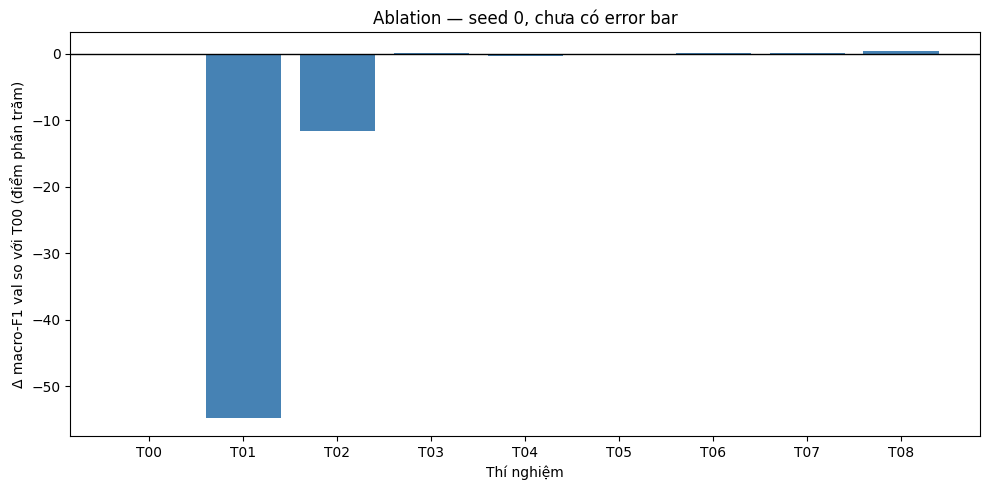

Tất cả thí nghiệm có đủ artifact.


In [38]:
plot_df = training_df.sort_values("exp_id")

colors = [
    "gray" if exp_id == "T00" else "steelblue"
    for exp_id in plot_df["exp_id"]
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    plot_df["exp_id"],
    plot_df["delta_percentage_points"],
    color=colors,
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Thí nghiệm")
ax.set_ylabel("Δ macro-F1 val so với T00 (điểm phần trăm)")
ax.set_title("Ablation — seed 0, chưa có error bar")

plt.tight_layout()
plt.savefig(
    WORK_DIR / "curves" / "training_ablation.png",
    dpi=160,
)
plt.show()

for exp_id in EXPERIMENTS:
    cfg = make_training_config(exp_id)
    directory = train.run_dir(cfg)

    assert (directory / "summary.json").is_file(), exp_id
    assert (directory / "history.csv").is_file(), exp_id
    assert (directory / "best.pt").is_file(), exp_id
    assert (directory / "val_logits.npz").is_file(), exp_id

    curve = WORK_DIR / "curves" / f"{exp_id}_seed0.png"
    assert curve.is_file(), f"Thiếu biểu đồ: {curve}"

print("Tất cả thí nghiệm có đủ artifact.")

### Nhận xét công thức huấn luyện

- Khởi tạo: scratch 0.421543, frozen 0.853550, finetune 0.968728;
  pretrained finetune hiệu quả nhất trong ngân sách 12 epoch.
- CutMix tăng 0.2007 điểm phần trăm; Mixup giảm 0.3084 điểm so với T00.
- Smoothing giảm 0.2130 điểm; focal tăng 0.0978 điểm; weighted CE tăng
  0.1106 điểm. Đây là sàng lọc một seed, chưa kết luận các mức tăng nhỏ vượt nhiễu.
- T08 CutMix+smoothing đạt 0.973579, tăng 0.4851 điểm, vượt cả từng yếu tố
  riêng trong seed0. Hiệu quả kết hợp không bằng cộng hiệu quả riêng lẻ.
- F01 chung kết tăng 0.4516 điểm macro-F1 test so với T00; std lớn nhất
  0.0844 điểm. Mức tăng vượt std theo rubric, không thay thế kiểm định thống kê.
- Trọng số lớp chỉ lấy từ train; seed không thay split.


## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [ ]:
%%writefile inference.py
import numpy as np
import copy
import torch
from torch.nn import functional as F


def softmax_numpy(logits):
    logits = np.asarray(logits, dtype=np.float64)
    logits = logits - logits.max(axis=1, keepdims=True)

    probabilities = np.exp(logits)
    return probabilities / probabilities.sum(
        axis=1, keepdims=True
    )


def view_identity(x):
    return x


def view_hflip(x):
    return x.flip(-1)


def views_multicrop(x, crop=224):
    height, width = x.shape[-2:]

    if crop > min(height, width):
        raise ValueError("Crop lớn hơn ảnh đầu vào")

    positions = [
        (0, 0),
        (0, width - crop),
        (height - crop, 0),
        (height - crop, width - crop),
        ((height - crop) // 2, (width - crop) // 2),
    ]

    return [
        x[:, :, top:top + crop, left:left + crop]
        for top, left in positions
    ]


def views_multiscale(x, sizes):
    """Caller must verify that its backbone supports the requested resolutions."""
    sizes = list(sizes)
    if not sizes or any(not isinstance(s, int) or s <= 0 for s in sizes):
        raise ValueError("sizes must contain positive integers")
    return [F.interpolate(x, size=(s, s), mode="bilinear", align_corners=False)
            for s in sizes]


def fuse_conv_bn(model):
    """Fuse proven forward pairs only; leave unknown architectures untouched.

    Supports adjacent Sequential Conv2d/BatchNorm2d and timm ResNet pairs.
    Named-child adjacency alone does not prove forward adjacency.
    """
    from torch import nn
    from timm.models.resnet import ResNet, BasicBlock, Bottleneck
    fused = copy.deepcopy(model).eval()

    def fuse_pair(parent, conv_name, bn_name):
        conv, bn = getattr(parent, conv_name), getattr(parent, bn_name)
        if isinstance(conv, nn.Conv2d) and isinstance(bn, nn.BatchNorm2d):
            setattr(parent, conv_name, torch.nn.utils.fusion.fuse_conv_bn_eval(conv, bn))
            setattr(parent, bn_name, nn.Identity())

    for module in list(fused.modules()):
        if isinstance(module, nn.Sequential):
            names = list(module._modules)
            for a, b in zip(names, names[1:]):
                fuse_pair(module, a, b)
        if isinstance(module, (BasicBlock, Bottleneck)):
            for index in (1, 2, 3):
                a, b = f"conv{index}", f"bn{index}"
                if hasattr(module, a) and hasattr(module, b):
                    fuse_pair(module, a, b)
        if isinstance(module, ResNet):
            fuse_pair(module, "conv1", "bn1")
    return fused


def aggregate_views(logits_per_view, space="prob"):
    if space == "prob":
        return np.mean(
            [softmax_numpy(z) for z in logits_per_view],
            axis=0,
        )

    if space == "logit":
        return softmax_numpy(
            np.mean(logits_per_view, axis=0)
        )

    raise ValueError(space)


def ensemble_probs(list_of_probs):
    probabilities = np.mean(list_of_probs, axis=0)
    return probabilities / probabilities.sum(
        axis=1, keepdims=True
    )


def fit_temperature(val_logits, val_labels):
    from scipy.optimize import minimize_scalar

    logits = torch.as_tensor(
        val_logits, dtype=torch.float64
    )
    labels = torch.as_tensor(
        val_labels, dtype=torch.long
    )

    def objective(log_temperature):
        temperature = np.exp(log_temperature)
        return F.cross_entropy(
            logits / temperature, labels
        ).item()

    result = minimize_scalar(
        objective,
        bounds=(np.log(0.05), np.log(20.0)),
        method="bounded",
    )

    if not result.success:
        raise RuntimeError(result.message)

    return float(np.exp(result.x))


def apply_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature phải > 0")

    return softmax_numpy(
        np.asarray(logits) / temperature
    )


@torch.inference_mode()
def predict_logits(model, loader, device, view=None):
    model.eval()

    names = []
    labels = []
    logits = []

    for images, targets, filenames in loader:
        images = images.to(device)

        if view is not None:
            images = view(images)

        output = model(images).float()

        names.extend(filenames)
        labels.append(targets.numpy())
        logits.append(output.cpu().numpy())

    return (
        names,
        np.concatenate(labels),
        np.concatenate(logits),
    )


@torch.inference_mode()
def forward_method(model, images, method, temperature=1.0):
    if method == "I01":
        views = [images, view_hflip(images)]
    elif method == "I02":
        views = views_multicrop(images, crop=224)
    elif method in ["I00", "I03", "I04"]:
        views = [images]
    else:
        raise ValueError(method)

    with torch.autocast(
        device_type=images.device.type,
        enabled=method == "I04" and images.is_cuda,
    ):
        logits = [model(view).float() for view in views]

    if method == "I03":
        return (logits[0] / temperature).softmax(dim=1)

    # TTA: trung bình xác suất của các view.
    return torch.stack([
        output.softmax(dim=1)
        for output in logits
    ]).mean(dim=0)


@torch.inference_mode()
def predict_method(
    model, loader, device, method, temperature=1.0
):
    model.eval()

    names = []
    labels = []
    probabilities = []

    for images, targets, filenames in loader:
        output = forward_method(
            model,
            images.to(device),
            method,
            temperature,
        )

        names.extend(filenames)
        labels.append(targets.numpy())
        probabilities.append(output.cpu().numpy())

    return (
        names,
        np.concatenate(labels),
        np.concatenate(probabilities),
    )


In [ ]:
%%writefile benchmark.py
import time
import copy
import numpy as np
import torch

from inference import forward_method


def bench(fn, warmup=10, iters=50, sync=None):
    if warmup < 10 or iters < 50:
        raise ValueError("Cần warmup >= 10 và iters >= 50")

    for _ in range(warmup):
        fn()

    times = []

    for _ in range(iters):
        if sync is not None:
            sync()

        start = time.perf_counter()
        fn()

        if sync is not None:
            sync()

        times.append((time.perf_counter() - start) * 1000)

    return {
        "p50": float(np.percentile(times, 50)),
        "p95": float(np.percentile(times, 95)),
        "p99": float(np.percentile(times, 99)),
        "mean": float(np.mean(times)),
        "n": iters,
    }


def method_latency(
    model,
    method,
    batch_size,
    device,
    temperature=1.0,
):
    model.eval()

    # Five-crop nhận ảnh 256; từng crop đưa vào model là 224.
    size = 256 if method == "I02" else 224

    images = torch.randn(
        batch_size, 3, size, size,
        device=device,
    )

    def predict():
        return forward_method(
            model, images, method, temperature
        )

    sync = (
        torch.cuda.synchronize
        if torch.device(device).type == "cuda"
        else None
    )

    measured = bench(
        predict,
        warmup=10,
        iters=50,
        sync=sync,
    )

    return {
        **measured,
        "batch": batch_size,
        "input_size": size,
        "model_input_size": 224,
        "dtype": "AMP" if method == "I04" else "FP32",
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.device(device).type == "cuda"
            else "CPU"
        ),
        "torch": torch.__version__,
        "images_per_s": batch_size / (measured["p50"] / 1000),
        "preprocessing_included": False,
        "view_operations_included": True,
        "fused_bn": False,
    }


def latency_report(model, batch_size, img_size, dtype="fp32", device="cuda",
                   warmup=10, iters=100, k_views=1):
    """Forward-only latency; copy model so FP16 does not mutate the caller."""
    device = torch.device(device)
    if dtype not in {"fp32", "amp", "fp16"}:
        raise ValueError(dtype)
    if dtype == "fp16" and device.type != "cuda":
        raise ValueError("FP16 benchmark requires CUDA")
    if not isinstance(k_views, int) or k_views < 1:
        raise ValueError("k_views must be a positive integer")
    measured_model = copy.deepcopy(model).to(device).float().eval()
    images = torch.randn(batch_size, 3, img_size, img_size, device=device)
    if dtype == "fp16":
        measured_model.half()
        images = images.half()

    @torch.inference_mode()
    def forward():
        with torch.autocast(device.type, enabled=dtype == "amp"):
            outputs = [measured_model(images).float().softmax(1)
                       for _ in range(k_views)]
            return torch.stack(outputs).mean(0)

    result = bench(forward, warmup, iters,
                   torch.cuda.synchronize if device.type == "cuda" else None)
    return dict(result, batch=batch_size, img_size=img_size, dtype=dtype,
                gpu=torch.cuda.get_device_name(device) if device.type == "cuda" else "CPU",
                torch=torch.__version__, images_per_s=batch_size/(result["p50"]/1000),
                preprocessing_included=False, k_views=k_views)


def tta_latency(model, k_views, **kw):
    """Measure K forwards and probability aggregation, not K * single latency.

    Synthetic equal-resolution views; notebook method_latency measures actual
    horizontal-flip/five-crop transformations for the reported experiments.
    """
    return latency_report(model, k_views=k_views, **kw)


In [46]:
import importlib
import inference
import benchmark

importlib.reload(inference)
importlib.reload(benchmark)

from torchvision import transforms as T
from eval import compute_metrics, save_predictions

device = torch.device("cuda")
assert torch.cuda.is_available()

CHOSEN_RECIPE = "T08"

chosen_cfg = make_training_config(CHOSEN_RECIPE)
checkpoint_dir = train.run_dir(chosen_cfg)

assert (checkpoint_dir / "best.pt").is_file()

inference_model = model.build_model(
    SELECTED_BACKBONE,
    pretrained=False,
).to(device)

checkpoint = torch.load(
    checkpoint_dir / "best.pt",
    map_location=device,
    weights_only=False,
)

inference_model.load_state_dict(checkpoint["model"])
inference_model.eval()

mean = inference_model.pretrained_cfg.get(
    "mean", dataset.IMAGENET_MEAN
)
std = inference_model.pretrained_cfg.get(
    "std", dataset.IMAGENET_STD
)

def make_inference_loader(df, method):
    if method == "I02":
        # Không center-crop trước, để 5 crop khác nhau.
        transform = T.Compose([
            T.Resize(256),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    else:
        transform = dataset.build_transforms(
            train=False,
            img_size=224,
            mean=mean,
            std=std,
        )

    return dataset.make_loader(
        df,
        IMAGES_DIR,
        transform,
        batch_size=COMMON["batch_size"],
        train=False,
        num_workers=2,
    )


# Khớp temperature từ logits VAL của checkpoint T08.
saved_val = np.load(checkpoint_dir / "val_logits.npz")

assert (
    saved_val["filenames"].tolist()
    == val_df["Filename"].astype(str).tolist()
)
assert np.array_equal(
    saved_val["y_true"],
    val_df["Label"].to_numpy(),
)

TEMPERATURE = inference.fit_temperature(
    saved_val["logits"],
    saved_val["y_true"],
)

print("Recipe:", CHOSEN_RECIPE)
print("Backbone:", SELECTED_BACKBONE)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Temperature khớp trên val:", TEMPERATURE)

before = inference.apply_temperature(
    saved_val["logits"], 1.0
)
after = inference.apply_temperature(
    saved_val["logits"], TEMPERATURE
)

assert np.array_equal(
    before.argmax(axis=1),
    after.argmax(axis=1),
)

print("Temperature scaling giữ nguyên nhãn dự đoán: OK")

Recipe: T08
Backbone: convnext_tiny
Checkpoint epoch: 11
Temperature khớp trên val: 0.6247070364510647
Temperature scaling giữ nguyên nhãn dự đoán: OK


In [47]:
METHODS = {
    "I00": {"name": "1-view", "K": 1},
    "I01": {"name": "TTA horizontal flip", "K": 2},
    "I02": {"name": "TTA five-crop", "K": 5},
    "I03": {"name": "Temperature scaling", "K": 1},
    "I04": {"name": "AMP inference", "K": 1},
}

inference_rows = []
latency_rows = []

for method, specification in METHODS.items():
    print("\nĐang chạy:", method, specification["name"])

    loader = make_inference_loader(val_df, method)

    names, y_true, probabilities = inference.predict_method(
        inference_model,
        loader,
        device,
        method,
        temperature=TEMPERATURE,
    )

    assert names == val_df["Filename"].astype(str).tolist()
    assert np.array_equal(y_true, val_df["Label"].to_numpy())

    metrics = compute_metrics(
        y_true,
        probabilities.argmax(axis=1),
        probabilities,
    )

    save_predictions(
        WORK_DIR / "predictions" / f"{method}_seed0_val.csv",
        names,
        y_true,
        probabilities,
    )

    latency_batch1 = None

    for batch_size in [1, 32]:
        measured = benchmark.method_latency(
            inference_model,
            method,
            batch_size,
            device,
            temperature=TEMPERATURE,
        )

        latency_rows.append({
            "exp_id": method,
            **measured,
        })

        if batch_size == 1:
            latency_batch1 = measured

    inference_rows.append({
        "exp_id": method,
        "method": specification["name"],
        "checkpoint": f"{CHOSEN_RECIPE}/seed0/best.pt",
        "K": specification["K"],
        "macro_f1_val": float(metrics["macro_f1"]),
        "top1_val": float(metrics["top1"]),
        "ece_val": float(metrics["ece"]),
        "temperature": (
            TEMPERATURE if method == "I03" else 1.0
        ),
        "p50_ms": latency_batch1["p50"],
        "p95_ms": latency_batch1["p95"],
        "p99_ms": latency_batch1["p99"],
    })

    # Lưu sau từng phương pháp.
    pd.DataFrame(inference_rows).to_csv(
        WORK_DIR / "inference_results.csv",
        index=False,
    )
    pd.DataFrame(latency_rows).to_csv(
        WORK_DIR / "latency_results.csv",
        index=False,
    )

inference_df = pd.DataFrame(inference_rows)
latency_df = pd.DataFrame(latency_rows)

baseline_latency = inference_df.loc[
    inference_df["exp_id"] == "I00", "p50_ms"
].iloc[0]

baseline_f1 = inference_df.loc[
    inference_df["exp_id"] == "I00", "macro_f1_val"
].iloc[0]

inference_df["relative_cost"] = (
    inference_df["p50_ms"] / baseline_latency
)
inference_df["delta_f1_percentage_points"] = (
    inference_df["macro_f1_val"] - baseline_f1
) * 100

throughput = latency_df.loc[
    latency_df["batch"] == 32,
    ["exp_id", "images_per_s"],
].rename(columns={
    "images_per_s": "throughput_batch32_images_per_s"
})

inference_df = inference_df.merge(
    throughput, on="exp_id"
)

inference_df.to_csv(
    WORK_DIR / "inference_results.csv",
    index=False,
)

display(inference_df)
display(latency_df)


Đang chạy: I00 1-view

Đang chạy: I01 TTA horizontal flip

Đang chạy: I02 TTA five-crop

Đang chạy: I03 Temperature scaling

Đang chạy: I04 AMP inference


,exp_id,method,checkpoint,K,macro_f1_val,top1_val,ece_val,temperature,p50_ms,p95_ms,p99_ms,relative_cost,delta_f1_percentage_points,throughput_batch32_images_per_s
0,I00,1-view,T08/seed0/best.pt,1,0.973579,0.978863,0.090253,1.000000,7.113152,10.251066,12.012648,1.000000,0.000000,263.614328
1,I01,TTA horizontal flip,T08/seed0/best.pt,2,0.975634,0.980577,0.093230,1.000000,16.560641,20.365199,28.065627,2.328172,0.205487,126.660909
2,I02,TTA five-crop,T08/seed0/best.pt,5,0.976302,0.980863,0.092673,1.000000,41.834835,58.754141,75.027851,5.881336,0.272275,47.381177
3,I03,Temperature scaling,T08/seed0/best.pt,1,0.973579,0.978863,0.004485,0.624707,9.849624,16.202105,18.555046,1.384706,0.000000,234.417030
4,I04,AMP inference,T08/seed0/best.pt,1,0.974100,0.979149,0.090673,1.000000,8.546095,9.271266,11.022076,1.201450,0.052127,627.967373


,exp_id,p50,p95,p99,mean,n,batch,input_size,model_input_size,dtype,gpu,torch,images_per_s,preprocessing_included,view_operations_included,fused_bn
0,I00,7.113152,10.251066,12.012648,7.428105,50,1,224,224,FP32,Tesla T4,2.11.0+cu130,140.584652,False,True,False
1,I00,121.389457,122.113934,123.618081,121.418194,50,32,224,224,FP32,Tesla T4,2.11.0+cu130,263.614328,False,True,False
2,I01,16.560641,20.365199,28.065627,17.323406,50,1,224,224,FP32,Tesla T4,2.11.0+cu130,60.384136,False,True,False
3,I01,252.643063,254.962327,255.793862,252.676240,50,32,224,224,FP32,Tesla T4,2.11.0+cu130,126.660909,False,True,False
4,I02,41.834835,58.754141,75.027851,44.375787,50,1,256,224,FP32,Tesla T4,2.11.0+cu130,23.903525,False,True,False
5,I02,675.373676,680.090113,680.819853,675.350480,50,32,256,224,FP32,Tesla T4,2.11.0+cu130,47.381177,False,True,False
6,I03,9.849624,16.202105,18.555046,10.876027,50,1,224,224,FP32,Tesla T4,2.11.0+cu130,101.526718,False,True,False
7,I03,136.508854,139.146085,139.686130,136.780560,50,32,224,224,FP32,Tesla T4,2.11.0+cu130,234.417030,False,True,False
8,I04,8.546095,9.271266,11.022076,8.675265,50,1,224,224,AMP,Tesla T4,2.11.0+cu130,117.012514,False,True,False
9,I04,50.958061,52.269789,52.463825,51.013793,50,32,224,224,AMP,Tesla T4,2.11.0+cu130,627.967373,False,True,False


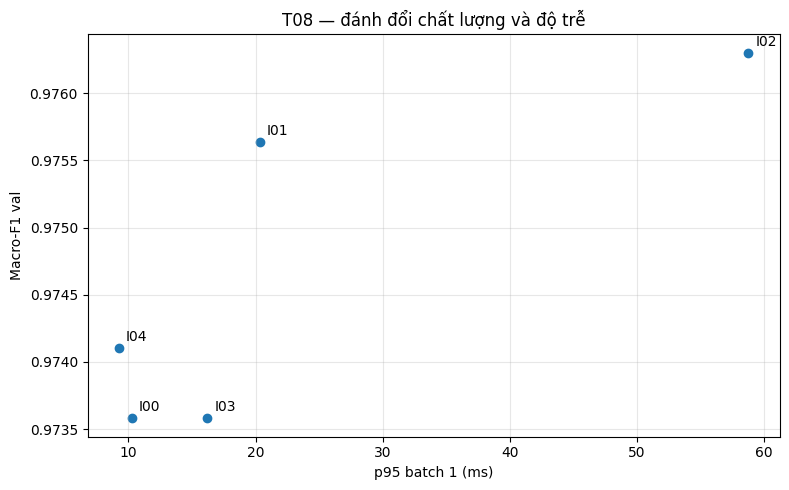

,exp_id,macro_f1_val,top1_val,ece_val,temperature
0,I00,0.973579,0.978863,0.090253,1.000000
3,I03,0.973579,0.978863,0.004485,0.624707


In [48]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    inference_df["p95_ms"],
    inference_df["macro_f1_val"],
)

for row in inference_df.itertuples():
    ax.annotate(
        row.exp_id,
        (row.p95_ms, row.macro_f1_val),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_xlabel("p95 batch 1 (ms)")
ax.set_ylabel("Macro-F1 val")
ax.set_title("T08 — đánh đổi chất lượng và độ trễ")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    WORK_DIR / "curves" / "inference_tradeoff.png",
    dpi=160,
)
plt.show()

display(
    inference_df.loc[
        inference_df["exp_id"].isin(["I00", "I03"]),
        [
            "exp_id",
            "macro_f1_val",
            "top1_val",
            "ece_val",
            "temperature",
        ],
    ]
)

## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, giữ `save_test_predictions=False` trong train; chạy test riêng sau khi chốt suy luận.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [49]:
import json
import gc
from pathlib import Path

SEEDS = [0, 1, 2]

FINAL_CHANGES = {
    "mix": "cutmix",
    "mix_alpha": 1.0,
    "loss": "ls",
    "label_smoothing": 0.1,
}

FINAL_METHOD = "I03"

# Lấy trực tiếp recipe baseline để giữ đúng cấu hình T00 đã chạy.
baseline_config_path = (
    WORK_DIR / "runs" / "T00" / "seed0" / "config.json"
)
BASELINE_CONFIG = json.loads(
    baseline_config_path.read_text()
)

assert BASELINE_CONFIG["backbone"] == "convnext_tiny"
assert BASELINE_CONFIG["save_test_predictions"] is False

def make_final_config(exp_id, seed):
    settings = BASELINE_CONFIG.copy()
    settings.update({
        "exp_id": exp_id,
        "seed": seed,
    })

    if exp_id == "F01":
        settings.update(FINAL_CHANGES)
    elif exp_id != "T00":
        raise ValueError(exp_id)

    return Config(**settings)


manifest = {
    "backbone": BASELINE_CONFIG["backbone"],
    "final_recipe": FINAL_CHANGES,
    "final_method": FINAL_METHOD,
    "baseline_method": "I00",
    "seeds": SEEDS,
    "epochs": BASELINE_CONFIG["epochs"],
    "batch_size": BASELINE_CONFIG["batch_size"],
}

manifest_path = WORK_DIR / "final_manifest.json"

if manifest_path.exists():
    assert json.loads(manifest_path.read_text()) == manifest, (
        "Cấu hình đã chốt khác với cấu hình hiện tại."
    )
else:
    manifest_path.write_text(
        json.dumps(manifest, indent=2)
    )

print(json.dumps(manifest, indent=2))

{
  "backbone": "convnext_tiny",
  "final_recipe": {
    "mix": "cutmix",
    "mix_alpha": 1.0,
    "loss": "ls",
    "label_smoothing": 0.1
  },
  "final_method": "I03",
  "baseline_method": "I00",
  "seeds": [
    0,
    1,
    2
  ],
  "epochs": 12,
  "batch_size": 32
}


In [56]:
for seed in SEEDS:
    for exp_id in ["F01", "T00"]:
        cfg = make_final_config(exp_id, seed)
        directory = train.run_dir(cfg)

        required_files = [
            "config.json",
            "summary.json",
            "best.pt",
            "val_logits.npz",
        ]

        completed = all(
            (directory / filename).is_file()
            for filename in required_files
        )

        if completed:
            stored_config = json.loads(
                (directory / "config.json").read_text()
            )

            from dataclasses import asdict
            assert stored_config == asdict(cfg)

            print("Đã hoàn thành, giữ nguyên:", exp_id, seed)
            continue

        print("\nĐang train:", exp_id, "seed", seed)
        run(cfg)

        gc.collect()
        torch.cuda.empty_cache()

print("Đã đủ 3 seed cho F01 và T00.")

Đã hoàn thành, giữ nguyên: F01 0
Đã hoàn thành, giữ nguyên: T00 0
Đã hoàn thành, giữ nguyên: F01 1
Đã hoàn thành, giữ nguyên: T00 1
Đã hoàn thành, giữ nguyên: F01 2
Đã hoàn thành, giữ nguyên: T00 2
Đã đủ 3 seed cho F01 và T00.
Đã hoàn thành, giữ nguyên: F01 0
Đã hoàn thành, giữ nguyên: T00 0
Đã hoàn thành, giữ nguyên: F01 1
Đã hoàn thành, giữ nguyên: T00 1
Đã hoàn thành, giữ nguyên: F01 2
Đã hoàn thành, giữ nguyên: T00 2
Đã đủ 3 seed cho F01 và T00.


In [57]:
PRED_DIR = WORK_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

for exp_id in ["F01", "T00"]:
    for seed in SEEDS:
        cfg = make_final_config(exp_id, seed)
        directory = train.run_dir(cfg)

        test_prediction_path = (
            PRED_DIR / f"{exp_id}_seed{seed}_test.csv"
        )
        val_prediction_path = (
            PRED_DIR / f"{exp_id}_seed{seed}_val.csv"
        )
        uncal_path = (
            PRED_DIR / f"F01uncal_seed{seed}_test.csv"
        )

        if test_prediction_path.exists():
            assert val_prediction_path.is_file()

            if exp_id == "F01":
                assert uncal_path.is_file()

            print("Đã có dự đoán, giữ nguyên:", exp_id, seed)
            continue

        # Đọc logit val của checkpoint tốt nhất.
        val_saved = np.load(directory / "val_logits.npz")

        val_names = val_saved["filenames"].astype(str).tolist()
        val_labels = val_saved["y_true"]
        val_logits = val_saved["logits"]

        assert val_names == val_df["Filename"].astype(str).tolist()
        assert np.array_equal(
            val_labels, val_df["Label"].to_numpy()
        )

        temperature = (
            inference.fit_temperature(val_logits, val_labels)
            if exp_id == "F01"
            else 1.0
        )

        val_probabilities = inference.apply_temperature(
            val_logits, temperature
        )

        save_predictions(
            val_prediction_path,
            val_names,
            val_labels,
            val_probabilities,
        )

        (directory / "calibration.json").write_text(
            json.dumps({
                "temperature": temperature,
                "fit_split": "val",
                "method": "I03" if exp_id == "F01" else "I00",
            }, indent=2)
        )

        # Cache logit để không forward test lại khi đã có kết quả.
        test_cache = directory / "test_logits.npz"
        started_marker = directory / "test.started"

        if test_cache.exists():
            saved_test = np.load(test_cache)
            test_names = saved_test["filenames"].astype(str).tolist()
            test_labels = saved_test["y_true"]
            test_logits = saved_test["logits"]

        else:
            if started_marker.exists():
                raise RuntimeError(
                    f"{exp_id} seed {seed}: lượt test trước bị ngắt. "
                    "Kiểm tra sự cố trước khi xử lý; không tự chạy lại."
                )

            final_model = model.build_model(
                cfg.backbone,
                pretrained=False,
                drop_rate=cfg.drop_rate,
            ).to(device)

            checkpoint = torch.load(
                directory / "best.pt",
                map_location=device,
                weights_only=False,
            )
            final_model.load_state_dict(checkpoint["model"])
            final_model.eval()

            eval_mean = final_model.pretrained_cfg.get(
                "mean", dataset.IMAGENET_MEAN
            )
            eval_std = final_model.pretrained_cfg.get(
                "std", dataset.IMAGENET_STD
            )

            test_loader = dataset.make_loader(
                test_df,
                cfg.images_dir,
                dataset.build_transforms(
                    train=False,
                    img_size=cfg.img_size,
                    mean=eval_mean,
                    std=eval_std,
                ),
                batch_size=cfg.batch_size,
                train=False,
                num_workers=cfg.num_workers,
            )

            started_marker.write_text(
                "Test forward started; configuration locked."
            )

            test_names, test_labels, test_logits = (
                inference.predict_logits(
                    final_model, test_loader, device
                )
            )

            temporary_cache = directory / "test_logits.tmp.npz"

            np.savez_compressed(
                temporary_cache,
                filenames=np.asarray(test_names),
                y_true=test_labels,
                logits=test_logits,
            )
            temporary_cache.replace(test_cache)

            del final_model, checkpoint
            gc.collect()
            torch.cuda.empty_cache()

        assert test_names == (
            test_df["Filename"].astype(str).tolist()
        )
        assert np.array_equal(
            test_labels, test_df["Label"].to_numpy()
        )

        if exp_id == "F01":
            save_predictions(
                uncal_path,
                test_names,
                test_labels,
                inference.apply_temperature(test_logits, 1.0),
            )

        save_predictions(
            test_prediction_path,
            test_names,
            test_labels,
            inference.apply_temperature(
                test_logits, temperature
            ),
        )

        print(
            "Đã lưu:", exp_id,
            "seed", seed,
            "| T =", round(temperature, 6),
        )

Đã có dự đoán, giữ nguyên: F01 0
Đã có dự đoán, giữ nguyên: F01 1
Đã có dự đoán, giữ nguyên: F01 2
Đã có dự đoán, giữ nguyên: T00 0
Đã có dự đoán, giữ nguyên: T00 1
Đã có dự đoán, giữ nguyên: T00 2


In [52]:
import subprocess
import sys

PRED_DIR = WORK_DIR / "predictions"
EVAL_OUT = WORK_DIR / "eval_out"

for tag in ["F01", "T00"]:
    subprocess.run([
        sys.executable,
        str(REPO_DIR / "eval.py"),
        "score",
        "--pred", str(PRED_DIR / f"{tag}_seed*_test.csv"),
        "--test-csv", str(LABELS_DIR / "test_subset0.csv"),
        "--labels", str(LABELS_DIR / "labels.csv"),
        "--tag", tag,
        "--out", str(EVAL_OUT),
    ], check=True)

In [53]:
cfg = make_final_config("F01", 0)
directory = train.run_dir(cfg)

final_model = model.build_model(
    cfg.backbone,
    pretrained=False,
    drop_rate=cfg.drop_rate,
).to(device)

final_model.load_state_dict(
    torch.load(
        directory / "best.pt",
        map_location=device,
        weights_only=False,
    )["model"]
)
final_model.eval()

temperature = json.loads(
    (directory / "calibration.json").read_text()
)["temperature"]

final_latency_rows = []

for batch_size in [1, 32]:
    measured = benchmark.method_latency(
        final_model,
        "I03",
        batch_size,
        device,
        temperature=temperature,
    )

    final_latency_rows.append({
        "exp_id": "F01",
        "seed": 0,
        **measured,
    })

final_latency_df = pd.DataFrame(final_latency_rows)
final_latency_df.to_csv(
    WORK_DIR / "final_latency_results.csv",
    index=False,
)

display(final_latency_df)

del final_model
gc.collect()
torch.cuda.empty_cache()

,exp_id,seed,p50,p95,p99,mean,n,batch,input_size,model_input_size,dtype,gpu,torch,images_per_s,preprocessing_included,view_operations_included,fused_bn
0,F01,0,6.436858,9.822567,9.864457,7.257632,50,1,224,224,FP32,Tesla T4,2.11.0+cu130,155.355311,False,True,False
1,F01,0,136.218901,138.130531,138.496516,136.314130,50,32,224,224,FP32,Tesla T4,2.11.0+cu130,234.916005,False,True,False


In [54]:
final_p95 = float(
    final_latency_df.loc[
        final_latency_df["batch"] == 1,
        "p95",
    ].iloc[0]
)

subprocess.run([
    sys.executable,
    str(REPO_DIR / "eval.py"),
    "grade",
    "--final", str(PRED_DIR / "F01_seed*_test.csv"),
    "--baseline", str(PRED_DIR / "T00_seed*_test.csv"),
    "--uncal", str(PRED_DIR / "F01uncal_seed*_test.csv"),
    "--final-val", str(PRED_DIR / "F01_seed*_val.csv"),
    "--test-csv", str(LABELS_DIR / "test_subset0.csv"),
    "--labels", str(LABELS_DIR / "labels.csv"),
    "--latency-p95-ms", str(final_p95),
    "--latency-method", "proper",
    "--out", str(EVAL_OUT),
], check=True)

CompletedProcess(args=['/usr/bin/python3', '/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/eval.py', 'grade', '--final', '/content/drive/MyDrive/2A202602800_NguyenVanHong/predictions/F01_seed*_test.csv', '--baseline', '/content/drive/MyDrive/2A202602800_NguyenVanHong/predictions/T00_seed*_test.csv', '--uncal', '/content/drive/MyDrive/2A202602800_NguyenVanHong/predictions/F01uncal_seed*_test.csv', '--final-val', '/content/drive/MyDrive/2A202602800_NguyenVanHong/predictions/F01_seed*_val.csv', '--test-csv', '/content/data/labels/test_subset0.csv', '--labels', '/content/data/labels/labels.csv', '--latency-p95-ms', '9.822566899310914', '--latency-method', 'proper', '--out', '/content/drive/MyDrive/2A202602800_NguyenVanHong/eval_out'], returncode=0)

In [3]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json

WORK_DIR = Path(
    "/content/drive/MyDrive/2A202602800_NguyenVanHong"
)
EVAL_OUT = WORK_DIR / "eval_out"

for filename in [
    "F01_summary.json",
    "T00_summary.json",
    "grade_I.json",
]:
    path = EVAL_OUT / filename

    print("\n" + "=" * 50)
    print(filename)

    if path.is_file():
        print(json.dumps(
            json.loads(path.read_text()),
            indent=2,
            ensure_ascii=False,
        ))
    else:
        print("Chưa tìm thấy file:", path)

Mounted at /content/drive

F01_summary.json
{
  "seeds": [
    0,
    1,
    2
  ],
  "top1": {
    "mean": 0.9788042961695655,
    "std": 0.001079537752266979
  },
  "macro_f1": {
    "mean": 0.9746621613076848,
    "std": 0.00025058602307323735
  },
  "balanced_acc": {
    "mean": 0.9782893886539727,
    "std": 0.00044717233229034733
  },
  "ece": {
    "mean": 0.005373659846022248,
    "std": 0.002666438620917596
  },
  "nll": {
    "mean": 0.07668815200351685,
    "std": 0.004684292124054337
  },
  "precision": {
    "mean": [
      0.9712254573253767,
      0.9646533652692727,
      0.9808907381722914,
      0.9853890669089865,
      0.9415799167200513,
      0.980229156524875,
      0.9756522774383959,
      0.9534482224699615,
      0.9881911872871204
    ],
    "std": [
      0.006840700190604785,
      0.006754994884918866,
      0.008141092561388638,
      0.004782808834936638,
      0.008482823917914576,
      0.008419154182986022,
      0.0067324880356328335,
      0.002845

### Kiểm tra helper trên CPU
Các kiểm tra dùng dữ liệu tổng hợp, không cập nhật số liệu thí nghiệm.


In [ ]:
%%writefile test_helpers.py
"""CPU checks for helpers; synthetic inputs, no dataset or test evaluation."""
import os
os.environ.setdefault("MPLBACKEND", "Agg")
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).resolve().parent))
import unittest
import torch
import numpy as np
import timm
import losses
import inference
import benchmark
import train
import model


class HelperTests(unittest.TestCase):
    def setUp(self):
        torch.manual_seed(0)
        np.random.seed(0)
        torch.set_num_threads(2)

    def test_losses_reduce_to_ce(self):
        z = torch.randn(8, 9); y = torch.randint(9, (8,))
        ce = torch.nn.functional.cross_entropy(z, y)
        torch.testing.assert_close(losses.FocalLoss(0)(z, y), ce)
        torch.testing.assert_close(losses.LabelSmoothingCE(0)(z, y), ce)

    def test_cutmix_area_and_loss(self):
        x = torch.stack([torch.full((3, 32, 32), float(i)) for i in range(8)])
        mixed, (a, b, lam) = losses.mix_batch(x, torch.arange(8))
        for i in range(8):
            if a[i] != b[i]:
                self.assertAlmostEqual((mixed[i, 0] != x[i, 0]).float().mean().item(), 1-lam)
        z = torch.randn(8, 9); criterion = torch.nn.CrossEntropyLoss()
        torch.testing.assert_close(losses.mixed_loss(criterion,z,(a,b,lam)),
                                   lam*criterion(z,a)+(1-lam)*criterion(z,b))

    def test_bn_fusion_sequential_and_resnet(self):
        modules = [torch.nn.Sequential(torch.nn.Conv2d(3,4,3,padding=1),torch.nn.BatchNorm2d(4)),
                   timm.create_model('resnet18',pretrained=False,num_classes=9)]
        x = torch.randn(2,3,32,32)
        for original in modules:
            original.eval(); fused = inference.fuse_conv_bn(original)
            with torch.inference_mode():
                torch.testing.assert_close(original(x),fused(x),atol=1e-5,rtol=1e-5)
            self.assertTrue(any(isinstance(m,torch.nn.BatchNorm2d) for m in original.modules()))

    def test_temperature_and_views(self):
        z = np.random.randn(12,9)
        p = inference.apply_temperature(z,.6)
        np.testing.assert_allclose(p.sum(1),1)
        np.testing.assert_array_equal(p.argmax(1),z.argmax(1))
        x = torch.randn(2,3,32,32)
        self.assertEqual([tuple(v.shape) for v in inference.views_multiscale(x,[16,24])],
                         [(2,3,16,16),(2,3,24,24)])
        self.assertEqual(len(inference.views_multicrop(x,24)),5)

    def test_ema_parameters_and_buffers(self):
        m = torch.nn.Sequential(torch.nn.Linear(3,3),torch.nn.BatchNorm1d(3))
        ema = train.EMA(m,.5)
        before = [p.clone() for p in ema.model.parameters()]
        with torch.no_grad():
            for p in m.parameters(): p.add_(2)
            m[1].running_mean.fill_(3)
            m[1].num_batches_tracked.fill_(7)
        ema.update(m)
        for old,new in zip(before,ema.model.parameters()): torch.testing.assert_close(new,old+1)
        torch.testing.assert_close(ema.model[1].running_mean,m[1].running_mean)
        self.assertEqual(ema.model[1].num_batches_tracked.item(),7)

    def test_cli_and_optimizer_groups(self):
        self.assertEqual(train.parse_overrides(['seed=2','amp=false','mix=none','class_weight_beta=.9']),
                         dict(seed=2,amp=False,mix=None,class_weight_beta=.9))
        for args in [['unknown=1'],['amp=yes'],['seed=none']]:
            with self.assertRaises(ValueError): train.parse_overrides(args)
        m=timm.create_model('resnet18',pretrained=False,num_classes=9)
        groups=model.param_groups(m,1e-4,1e-3,.05)
        ids=[id(p) for g in groups for p in g['params']]
        self.assertEqual(len(ids),len(set(ids)))
        self.assertEqual(set(ids),{id(p) for p in m.parameters() if p.requires_grad})
        for g in groups:
            for p in g['params']:
                if p.ndim<=1: self.assertEqual(g['weight_decay'],0)

    def test_cpu_latency_helpers(self):
        m=torch.nn.Sequential(torch.nn.Flatten(),torch.nn.Linear(3*8*8,9)).eval()
        for result in [benchmark.latency_report(m,1,8,device='cpu',iters=50),
                       benchmark.tta_latency(m,2,batch_size=1,img_size=8,device='cpu',iters=50)]:
            self.assertEqual(result['n'],50)
            self.assertLessEqual(result['p50'],result['p95'])
            self.assertLessEqual(result['p95'],result['p99'])


if __name__ == '__main__':
    unittest.main()


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, str(CODE_DIR / "test_helpers.py"), "-v"], check=True)


## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [9]:
%pip -q install pandas numpy openpyxl matplotlib pillow

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import sys
import json
import shutil
import hashlib
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

WORK_DIR = Path(
    "/content/drive/MyDrive/2A202602800_NguyenVanHong"
)
REPO_DIR = Path(
    "/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance"
)

PRED_DIR = WORK_DIR / "predictions"
EVAL_OUT = WORK_DIR / "eval_out"
CURVES_DIR = WORK_DIR / "curves"
CURVES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_DIR))
from eval import compute_metrics


def read_json(path):
    return json.loads(
        Path(path).read_text(encoding="utf-8")
    )


final_summary = read_json(EVAL_OUT / "F01_summary.json")
baseline_summary = read_json(EVAL_OUT / "T00_summary.json")
grade = read_json(EVAL_OUT / "grade_I.json")

CLASS_NAMES = final_summary["classes"]

print("Đã đọc kết quả.")
print("Macro-F1 test F01:", final_summary["macro_f1"])
print("Macro-F1 test T00:", baseline_summary["macro_f1"])
print("Điểm đề xuất phần I:", grade["total"], "/ 20")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã đọc kết quả.
Macro-F1 test F01: {'mean': 0.9746621613076848, 'std': 0.00025058602307323735}
Macro-F1 test T00: {'mean': 0.9701461821479533, 'std': 0.0008439977115901302}
Điểm đề xuất phần I: 19 / 20


In [ ]:
# 1. Backbones
backbones_df = pd.read_csv(
    WORK_DIR / "backbone_results.csv"
)

# 2. Training
descriptions = {
    "T00": ("Baseline", "Finetune + basic + CE"),
    "T01": ("A", "Scratch"),
    "T02": ("A", "Frozen backbone"),
    "T03": ("B", "CutMix"),
    "T04": ("B", "Mixup"),
    "T05": ("C", "Label smoothing 0.1"),
    "T06": ("C", "Focal gamma=2"),
    "T07": ("C", "Weighted CE"),
    "T08": ("Combination", "CutMix + label smoothing 0.1"),
}

training_rows = []

for exp_id, (axis, description) in descriptions.items():
    directory = WORK_DIR / "runs" / exp_id / "seed0"
    cfg = read_json(directory / "config.json")
    summary = read_json(directory / "summary.json")

    saved = np.load(directory / "val_logits.npz")
    logits = saved["logits"].astype(np.float64)
    logits -= logits.max(axis=1, keepdims=True)

    probabilities = np.exp(logits)
    probabilities /= probabilities.sum(axis=1, keepdims=True)

    metrics = compute_metrics(
        saved["y_true"],
        probabilities.argmax(axis=1),
        probabilities,
    )

    training_rows.append({
        **summary,
        "axis": axis,
        "description": description,
        "init": cfg["init"],
        "aug": cfg["aug"],
        "mix": cfg["mix"],
        "loss": cfg["loss"],
        "label_smoothing": cfg["label_smoothing"],
        "focal_gamma": cfg["focal_gamma"],
        "chinee_apple_f1_val": float(metrics["f1"][0]),
        "snake_weed_f1_val": float(metrics["f1"][7]),
        "notes": "Sàng lọc 1 seed",
    })

training_df = pd.DataFrame(training_rows)

baseline_val = training_df.loc[
    training_df.exp_id == "T00",
    "macro_f1_val",
].iloc[0]

training_df["delta_vs_T00"] = (
    training_df.macro_f1_val - baseline_val
)
training_df["delta_percentage_points"] = (
    training_df.delta_vs_T00 * 100
)

# 3. Inference
inference_df = pd.read_csv(
    WORK_DIR / "inference_results.csv"
)

# 4. Latency
latency_df = pd.read_csv(
    WORK_DIR / "latency_results.csv"
)
final_latency_df = pd.read_csv(
    WORK_DIR / "final_latency_results.csv"
)

latency_df["stage"] = "Bước 3 - T08 seed0"
final_latency_df["stage"] = "Chung kết - F01 seed0"

all_latency_df = pd.concat(
    [latency_df, final_latency_df],
    ignore_index=True,
)

# 5. Final và 6. PerClass
final_rows = []
perclass_rows = []
confusions = {}

for exp_id in ["F01", "T00"]:
    for seed in [0, 1, 2]:
        test_pred = pd.read_csv(
            PRED_DIR / f"{exp_id}_seed{seed}_test.csv"
        )
        val_pred = pd.read_csv(
            PRED_DIR / f"{exp_id}_seed{seed}_val.csv"
        )

        test_probs = test_pred[
            [f"p{i}" for i in range(9)]
        ].to_numpy()

        val_probs = val_pred[
            [f"p{i}" for i in range(9)]
        ].to_numpy()

        tm = compute_metrics(
            test_pred.y_true.to_numpy(),
            test_pred.y_pred.to_numpy(),
            test_probs,
        )
        vm = compute_metrics(
            val_pred.y_true.to_numpy(),
            val_pred.y_pred.to_numpy(),
            val_probs,
        )

        final_rows.append({
            "exp_id": exp_id,
            "seed": str(seed),
            "backbone": "convnext_tiny",
            "recipe": (
                "CutMix + label smoothing 0.1"
                if exp_id == "F01"
                else "Basic + CE"
            ),
            "inference": (
                "1-view + temperature scaling"
                if exp_id == "F01"
                else "1-view"
            ),
            "macro_f1_val": float(vm["macro_f1"]),
            "macro_f1_test": float(tm["macro_f1"]),
            "top1_test": float(tm["top1"]),
            "ece_test": float(tm["ece"]),
        })

        for label, name in enumerate(CLASS_NAMES):
            perclass_rows.append({
                "exp_id": exp_id,
                "seed": str(seed),
                "class": name,
                "support": int(tm["support"][label]),
                "precision": float(tm["precision"][label]),
                "recall": float(tm["recall"][label]),
                "f1": float(tm["f1"][label]),
            })

        confusions[(exp_id, seed)] = tm["confusion"]

seed_results_df = pd.DataFrame(final_rows)
final_aggregate_rows = []

for exp_id in ["F01", "T00"]:
    group = seed_results_df[
        seed_results_df.exp_id == exp_id
    ]

    official = (
        final_summary if exp_id == "F01"
        else baseline_summary
    )

    for column, key in [
        ("macro_f1_test", "macro_f1"),
        ("top1_test", "top1"),
        ("ece_test", "ece"),
    ]:
        assert np.isclose(
            group[column].mean(),
            official[key]["mean"],
        )
        assert np.isclose(
            group[column].std(ddof=1),
            official[key]["std"],
        )

    for statistic in ["mean", "std"]:
        row = group.iloc[0].to_dict()
        row["seed"] = statistic

        for metric in [
            "macro_f1_val",
            "macro_f1_test",
            "top1_test",
            "ece_test",
        ]:
            row[metric] = (
                group[metric].mean()
                if statistic == "mean"
                else group[metric].std(ddof=1)
            )

        final_aggregate_rows.append(row)

final_df = pd.concat([
    seed_results_df,
    pd.DataFrame(final_aggregate_rows),
], ignore_index=True)

perclass_seed_df = pd.DataFrame(perclass_rows)
perclass_aggregate_rows = []

for (exp_id, class_name), group in perclass_seed_df.groupby(
    ["exp_id", "class"], sort=False
):
    for statistic in ["mean", "std"]:
        row = {
            "exp_id": exp_id,
            "class": class_name,
            "seed": statistic,
            # Support là số ảnh thật, không phải std của support.
            "support": int(group.support.iloc[0]),
        }

        for metric in ["precision", "recall", "f1"]:
            row[metric] = (
                group[metric].mean()
                if statistic == "mean"
                else group[metric].std(ddof=1)
            )

        perclass_aggregate_rows.append(row)

perclass_df = pd.concat([
    perclass_seed_df,
    pd.DataFrame(perclass_aggregate_rows),
], ignore_index=True)

# 7. Summary: top 10 cấu hình huấn luyện theo val.
summary_df = pd.concat([
    backbones_df.assign(stage="Backbone"),
    training_df.assign(stage="Training"),
], ignore_index=True)

latency_lookup = backbones_df.set_index("backbone")[
    "latency_p95_ms"
].to_dict()

summary_df["backbone_1view_p95_ms_reference"] = (
    summary_df.backbone.map(latency_lookup)
)
summary_df["latency_note"] = (
    "Tham khảo checkpoint Bước 1; không đo lại mọi recipe"
)

summary_df = summary_df.sort_values(
    "macro_f1_val", ascending=False
).head(10)

# Compact Summary; detailed data remain in the other sheets.
summary_df = pd.DataFrame({
    'exp_id': summary_df.exp_id, 'stage': summary_df.stage,
    'backbone': summary_df.backbone,
    'recipe': summary_df.description.fillna('Basic + CE'),
    'macro_f1_val (0-1)': summary_df.macro_f1_val,
    'top1_val (0-1)': summary_df.top1_val,
    'delta_vs_T00 (percentage points)': summary_df.delta_percentage_points,
    'params (M)': summary_df.params_M, 'GMAC (fvcore)': summary_df.gmac,
    'train_seconds_per_epoch (s)': summary_df.train_seconds_per_epoch,
    'reference_p95_batch1 (ms)': summary_df.backbone_1view_p95_ms_reference,
    'latency_note': summary_df.latency_note,
})

sheets = {
    "Backbones": backbones_df,
    "Training": training_df,
    "Inference": inference_df,
    "Final": final_df,
    "PerClass": perclass_df,
    "Latency": all_latency_df,
    "Summary": summary_df,
}

from openpyxl.styles import Font, PatternFill

with pd.ExcelWriter(
    WORK_DIR / "results.xlsx",
    engine="openpyxl",
) as writer:
    for name, frame in sheets.items():
        frame.to_excel(
            writer, sheet_name=name, index=False
        )

        ws = writer.sheets[name]
        ws.freeze_panes = "A2"
        ws.auto_filter.ref = ws.dimensions

        for cell in ws[1]:
            cell.font = Font(bold=True, color="FFFFFF")
            cell.fill = PatternFill(
                "solid", fgColor="305496"
            )

        for column in ws.columns:
            width = max(
                len(str(cell.value or ""))
                for cell in list(column)[:40]
            )
            ws.column_dimensions[
                column[0].column_letter
            ].width = min(45, max(14, width + 2))

        for row in ws.iter_rows(min_row=2):
            for cell in row:
                if isinstance(cell.value, float):
                    cell.number_format = "0.000000"

        if "macro_f1_val" in frame.columns and not frame.empty:
            best_position = int(np.argmax(
                frame["macro_f1_val"].to_numpy()
            ))
            for cell in ws[best_position + 2]:
                cell.fill = PatternFill(
                    "solid", fgColor="E2F0D9"
                )

print("Đã tạo results.xlsx, đủ 7 sheet.")
print("Mean/std test khớp eval.py.")
print("Metric dùng tỷ lệ 0–1; latency dùng ms.")
display(final_df)

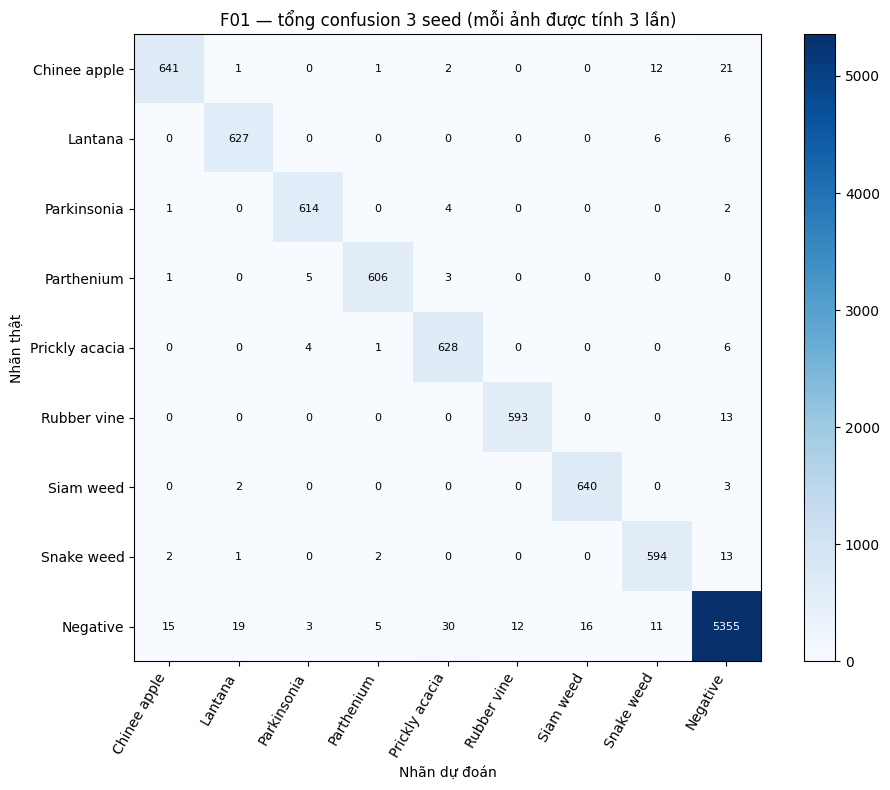

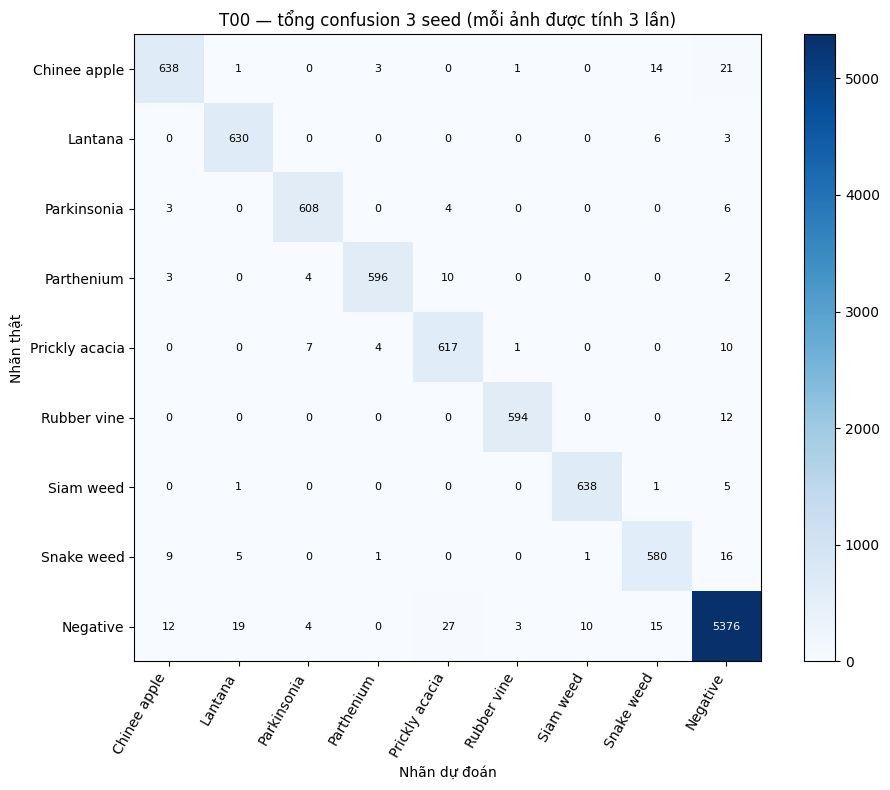

Số ảnh sai của F01 seed0: 76


,Filename,true_class,pred_class
16,20161207-143344-0.jpg,Snake weed,Negative
56,20170128-102632-0.jpg,Negative,Lantana
88,20170130-102525-0.jpg,Lantana,Negative
90,20170130-102736-0.jpg,Lantana,Negative
102,20170207-153455-0.jpg,Chinee apple,Snake weed
269,20170405-160310-0.jpg,Negative,Chinee apple
274,20170410-124556-0.jpg,Chinee apple,Negative
300,20170501-144548-0.jpg,Negative,Snake weed
310,20170521-153419-0.jpg,Lantana,Snake weed
311,20170521-153505-0.jpg,Lantana,Snake weed


In [11]:
for exp_id in ["F01", "T00"]:
    cm = sum(
        confusions[(exp_id, seed)]
        for seed in [0, 1, 2]
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(cm, cmap="Blues")
    fig.colorbar(image, ax=ax)

    ax.set_xticks(
        range(9), CLASS_NAMES,
        rotation=60, ha="right",
    )
    ax.set_yticks(range(9), CLASS_NAMES)
    ax.set_xlabel("Nhãn dự đoán")
    ax.set_ylabel("Nhãn thật")
    ax.set_title(
        f"{exp_id} — tổng confusion 3 seed "
        "(mỗi ảnh được tính 3 lần)"
    )

    for i in range(9):
        for j in range(9):
            ax.text(
                j, i, str(int(cm[i, j])),
                ha="center", va="center",
                fontsize=8,
                color=(
                    "white" if cm[i, j] > cm.max()/2
                    else "black"
                ),
            )

    plt.tight_layout()
    plt.savefig(
        CURVES_DIR / f"{exp_id}_confusion_sum.png",
        dpi=160,
    )
    plt.show()

pred = pd.read_csv(
    PRED_DIR / "F01_seed0_test.csv"
)

errors = pred[
    pred.y_true != pred.y_pred
].copy()

name_map = dict(enumerate(CLASS_NAMES))
errors["true_class"] = errors.y_true.map(name_map)
errors["pred_class"] = errors.y_pred.map(name_map)

errors.to_csv(
    WORK_DIR / "F01_seed0_errors.csv",
    index=False,
)

print("Số ảnh sai của F01 seed0:", len(errors))

display(
    errors[
        ["Filename", "true_class", "pred_class"]
    ].head(20)
)

In [12]:
DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = DATA_DIR / "images.zip"

if not ZIP_PATH.exists():
    print("Đang tải ảnh...")
    urllib.request.urlretrieve(
        "https://zenodo.org/records/7939060/files/images.zip?download=1",
        ZIP_PATH,
    )

digest = hashlib.md5()

with ZIP_PATH.open("rb") as f:
    for chunk in iter(
        lambda: f.read(1024 * 1024), b""
    ):
        digest.update(chunk)

assert digest.hexdigest() == (
    "b7b30f96d466fba86016aa5a26606e0f"
), "Checksum sai. Xóa ZIP lỗi rồi tải lại."

image_files = list(DATA_DIR.rglob("*.jpg"))

if len(image_files) != 17509:
    print("Đang giải nén...")
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR)

image_files = list(DATA_DIR.rglob("*.jpg"))
assert len(image_files) == 17509

IMAGES_DIR = image_files[0].parent

assert all(
    (IMAGES_DIR / filename).is_file()
    for filename in pred.Filename
)

print("Thư mục ảnh:", IMAGES_DIR)
print("Số ảnh:", len(image_files))

Đang tải ảnh...
Đang giải nén...
Thư mục ảnh: /content/data
Số ảnh: 17509


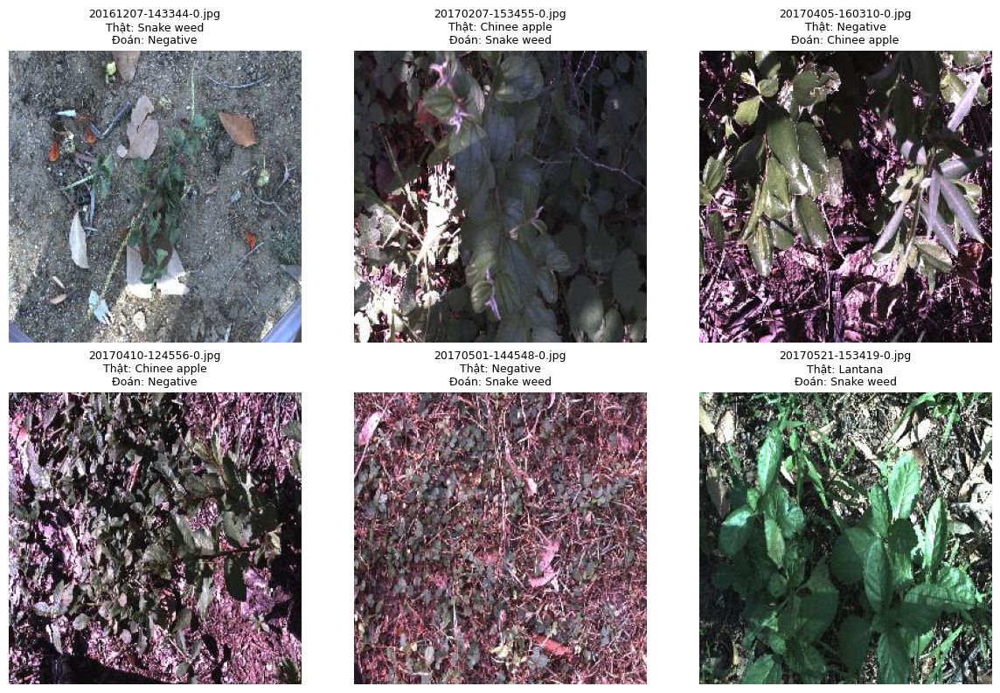

In [13]:
selected_errors = errors[
    errors.y_true.isin([0, 7])
    | errors.y_pred.isin([0, 7])
].head(6)

if selected_errors.empty:
    selected_errors = errors.head(6)

if selected_errors.empty:
    print("Không có ảnh sai ở seed0.")
else:
    fig, axes = plt.subplots(
        2, 3, figsize=(12, 8)
    )
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, row in zip(
        axes, selected_errors.itertuples()
    ):
        with Image.open(
            IMAGES_DIR / row.Filename
        ) as image:
            ax.imshow(image.convert("RGB"))

        ax.set_title(
            f"{row.Filename}\n"
            f"Thật: {row.true_class}\n"
            f"Đoán: {row.pred_class}",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig(
        CURVES_DIR / "F01_error_examples.png",
        dpi=160,
    )
    plt.show()

In [ ]:
NOTEBOOK_URL = (
    "https://colab.research.google.com/drive/"
    "1hHWr3tceI_zQFmJ2MLObZo4HFrgQvVIu"
)

ERROR_ANALYSIS = """
Trong sáu ảnh sai của F01 seed0 được chọn để minh họa,
Snake weed bị dự đoán thành Negative; Chinee apple bị nhầm
thành Snake weed hoặc Negative. Hai ảnh Negative và một ảnh
Lantana cũng bị dự đoán thành các lớp mục tiêu.

Ảnh Snake weed bị nhầm thành Negative có nhiều nền đất và vật
rơi trên mặt đất, trong khi cây chiếm phần nhỏ khung hình.
Một số ảnh khác có nhiều lá, cành đan xen, vùng bóng tối và
vùng sáng mạnh, khiến đặc điểm của cây mục tiêu khó quan sát.
Đây có thể là các yếu tố góp phần gây nhầm lẫn.

Các ví dụ cho thấy lỗi xảy ra cả giữa các loài mục tiêu và giữa
loài mục tiêu với Negative. Tuy nhiên, đây là một nhóm ảnh được
chọn có liên quan đến Chinee apple hoặc Snake weed, không đại diện
cho toàn bộ lỗi. Cần đối chiếu confusion matrix để xác định
những cặp nhầm lẫn phổ biến. Các nguyên nhân nêu trên là giả thuyết
từ quan sát ảnh, chưa được kiểm chứng.
""".strip()

assert "ĐIỀN" not in ERROR_ANALYSIS

print("Đã bổ sung phân tích ảnh sai.")

In [ ]:
# Báo cáo dựa trên các artifact đã kiểm tra; không train/test lại.
REPORT_TEXT = '# Báo cáo Lab Day 2 — DeepWeeds\n\nSinh viên: Nguyễn Văn Hồng  \nMSSV: 2A202602800  \nNotebook: https://colab.research.google.com/drive/1hHWr3tceI_zQFmJ2MLObZo4HFrgQvVIu\n\n## 1. Tóm tắt\n\nSo sánh 5 backbone, ablation ba trục khởi tạo, augmentation và loss,\nrồi thử 4 phương pháp suy luận ngoài mốc 1-view.\nCấu hình cuối dùng ConvNeXt-Tiny, CutMix, label smoothing 0.1\nvà temperature scaling.\n\nQua 3 seed, macro-F1 test đạt 0.974662 ± 0.000251,\ntop-1 đạt 0.978804 ± 0.001080.\nMacro-F1 tăng 0.4516 điểm phần trăm so với baseline.\neval.py đề xuất 19/20 cho phần I,\nkhông phải điểm tổng bài lab.\n\n## 2. Dữ liệu và thiết lập\n\nDùng nguyên bản fold 0: 10.501 train, 3.501 val và 3.507 test.\nGiao từng cặp bằng 0; hợp có 17.509 ảnh.\nKhông tự chia lại hoặc gộp val vào train.\n\n![Phân bố lớp](curves/EDA_class_distribution.png)\n\nNegative có 9.106/17.509 ảnh (52,01%); Rubber vine ít nhất với 1.009 ảnh.\nTỷ lệ lớp lớn nhất/nhỏ nhất là 9,02 lần. Mô hình chỉ đoán Negative có thể\nđạt khoảng 52% accuracy trên toàn bộ dữ liệu, nên macro-F1 là chỉ số chọn\ncheckpoint và recipe. Số đếm từng lớp được đối chiếu với bảng tham khảo\ntrong README, không sửa CSV để ép khớp.\n\n![Ảnh mẫu từng lớp](curves/EDA_samples.png)\n\nKiểm tra pipeline: loss đầu 2,1949, gần ln(9)=2,1972; một batch nhỏ\nđạt CE 0,004214 và accuracy 100%. Đây là kiểm tra khả năng học thuộc,\nkhông phải chất lượng tổng quát hóa. Ảnh sau augmentation được giải\nchuẩn hóa và kiểm tra cùng nhãn.\n\n\nHuấn luyện 12 epoch, batch 32, AdamW; LR backbone 1e-4,\nhead 1e-3; weight decay 0.05, không áp dụng cho norm/bias.\nWarmup 1 epoch và cosine theo iteration, AMP khi train.\nTrain dùng random resized crop 224 và horizontal flip;\nval/test resize 256 rồi center crop 224.\nMean/std lấy từ pretrained_cfg.\n\nSàng lọc dùng seed 0; chung kết dùng seed 0,1,2.\nCheckpoint theo macro-F1 val cao nhất, hòa giữ epoch sớm hơn.\nPhiên bản và GPU xem logs/*/seed*/environment.json.\n\n## 3. So sánh backbone\n\n| exp_id | backbone | tag | params_M | gmac | macro_f1_val | top1_val | latency_p95_ms |\n| --- | --- | --- | --- | --- | --- | --- | --- |\n| B03 | convnext_tiny | in12k_ft_in1k | 27.827049 | 4.469676 | 0.968728 | 0.976292 | 10.680635 |\n| B04 | deit_small_patch16_224 | fb_in1k | 21.669129 | 4.250294 | 0.947138 | 0.962296 | 9.026484 |\n| B01 | resnet50 | a1_in1k | 23.526473 | 4.109483 | 0.82684 | 0.872608 | 10.623503 |\n| B05 | mobilenetv3_large_100 | ra_in1k | 4.213561 | 0.224168 | 0.766247 | 0.82405 | 8.524475 |\n| B02 | resnext50_32x4d | a1h_in1k | 22.998345 | 4.257352 | 0.765552 | 0.820051 | 25.015488 |\n\nConvNeXt-Tiny có macro-F1 val cao nhất trong lần sàng lọc,\nvới độ trễ phù hợp và được chọn để ablation.\nTag in12k_ft_in1k khác nguồn pretrained của các backbone khác,\nnên chênh lệch không thể quy riêng cho kiến trúc.\nGMAC dùng fvcore, một multiply-add tính một đơn vị;\ntoán tử chưa hỗ trợ được ghi trong output.\nMột seed chưa đủ để kết luận chắc chắn về thứ hạng.\n\nTheo history.csv, B03/T00 seed0 đạt macro-F1 val cao nhất ở epoch 10\n(0,968728), sau đó giảm nhẹ còn 0,967065 ở epoch 12 dù train loss giảm\nđến 0,035559. Đây là dấu hiệu chất lượng val đã bão hòa, chưa đủ để\nkhẳng định quá khớp nghiêm trọng. B04 tiếp tục tăng và đạt tốt nhất\nở epoch 12 (0,947138). T08 tốt nhất ở epoch 11 (0,973579), epoch 12\nlà 0,973112. Các dao động val giải thích việc chọn checkpoint tốt nhất\nthay vì mặc định dùng epoch cuối. Khi dùng smoothing/CutMix, train loss\nvà val CE khác objective nên không suy diễn quá khớp từ khoảng cách loss.\n\n\n## 4. Công thức huấn luyện\n\n| exp_id | description | macro_f1_val | delta_percentage_points |\n| --- | --- | --- | --- |\n| T00 | Finetune + basic + CE | 0.968728 | 0.0 |\n| T01 | Scratch | 0.421543 | -54.718488 |\n| T02 | Frozen backbone | 0.85355 | -11.517756 |\n| T03 | CutMix | 0.970735 | 0.200671 |\n| T04 | Mixup | 0.965644 | -0.308427 |\n| T05 | Label smoothing 0.1 | 0.966598 | -0.213031 |\n| T06 | Focal gamma=2 | 0.969706 | 0.09777 |\n| T07 | Weighted CE | 0.969834 | 0.110624 |\n| T08 | CutMix + label smoothing 0.1 | 0.973579 | 0.485108 |\n\nScratch và frozen kém finetune trong cùng ngân sách 12 epoch.\nCutMix riêng lẻ cải thiện val; label smoothing riêng lẻ giảm điểm.\nKết hợp hai yếu tố đạt macro-F1 val 0.973579,\ncao nhất trong nhóm recipe đã thử.\nHiệu quả kết hợp không bằng cộng cơ học hiệu quả từng yếu tố.\n\nCác ablation dùng một seed để sàng lọc.\nTrain loss có thể dùng objective khác, còn val loss luôn là CE.\n\n![Ablation](curves/training_ablation.png)\n\n## 5. Suy luận\n\n| exp_id | method | macro_f1_val | ece_val | p95_ms |\n| --- | --- | --- | --- | --- |\n| I00 | 1-view | 0.973579 | 0.090253 | 10.251066 |\n| I01 | TTA horizontal flip | 0.975634 | 0.09323 | 20.365199 |\n| I02 | TTA five-crop | 0.976302 | 0.092673 | 58.754141 |\n| I03 | Temperature scaling | 0.973579 | 0.004485 | 16.202105 |\n| I04 | AMP inference | 0.9741 | 0.090673 | 9.271266 |\n\nFive-crop đạt macro-F1 val cao nhất nhưng có chi phí nhiều view.\nChọn I03 để cân bằng chất lượng, hiệu chuẩn và chi phí.\nTrên T08 seed0, temperature 0.624707 giảm ECE val\ntừ 0.090253 xuống 0.004485, không đổi nhãn dự đoán.\n\nBenchmark dùng 10 warmup và 50 lần đo, đồng bộ CUDA,\nbatch 1 và 32 trên T4. Không tính đọc ảnh, tiền xử lý PIL\nvà chuyển CPU lên GPU; có tính thao tác view/gộp xác suất.\n\n![Đánh đổi suy luận](curves/inference_tradeoff.png)\n\n## 6. Chung kết\n\n- F01 macro-F1 test: 0.974662 ± 0.000251.\n- T00 macro-F1 test: 0.970146 ± 0.000844.\n- F01 top-1 test: 0.978804 ± 0.001080.\n- F01 ECE test: 0.005374 ± 0.002666.\n\nStd mẫu dùng ddof=1. Mức tăng 0.004516 lớn hơn std lớn nhất\ncủa hai nhóm (0.000844), theo tiêu chí rubric;\nđây không phải kiểm định ý nghĩa thống kê.\n\nMỗi seed khớp T trên val. Test forward một lượt/model;\nbản chưa và sau hiệu chuẩn dùng chung logits.\nKhông thay đổi cấu hình sau khi xem test.\n\n### Chỉ số từng lớp — F01, mean 3 seed\n\n| class | support | precision | recall | f1 |\n| --- | --- | --- | --- | --- |\n| Chinee apple | 226 | 0.971225 | 0.945428 | 0.95815 |\n| Lantana | 213 | 0.964653 | 0.981221 | 0.972852 |\n| Parkinsonia | 207 | 0.980891 | 0.988728 | 0.984773 |\n| Parthenium | 205 | 0.985389 | 0.985366 | 0.985366 |\n| Prickly acacia | 213 | 0.94158 | 0.982786 | 0.961727 |\n| Rubber vine | 202 | 0.980229 | 0.978548 | 0.979362 |\n| Siam weed | 215 | 0.975652 | 0.992248 | 0.983865 |\n| Snake weed | 204 | 0.953448 | 0.970588 | 0.961941 |\n| Negative | 1822 | 0.988191 | 0.979693 | 0.983923 |\n\n![Confusion](curves/F01_confusion_sum.png)\n\nConfusion matrix tổng ba seed tính mỗi ảnh ba lần.\n\nTrong confusion tổng ba seed (10.521 lượt dự đoán, không phải 10.521 ảnh\nđộc lập), các lỗi nhiều nhất là Negative → Prickly acacia: 30 lượt,\nChinee apple → Negative: 21 lượt và Negative → Lantana: 19 lượt.\nChinee apple → Snake weed có 12 lượt; chiều ngược lại có 2 lượt.\nNhư vậy cặp Chinee apple/Snake weed có xuất hiện nhưng không phải cặp lỗi\nlớn nhất của F01. Số lượt này không cho biết số ảnh sai duy nhất giữa seed.\n\n\n### Phân tích lỗi\n\nTrong sáu ảnh sai của F01 seed0 được chọn để minh họa,\nSnake weed bị dự đoán thành Negative; Chinee apple bị nhầm\nthành Snake weed hoặc Negative. Hai ảnh Negative và một ảnh\nLantana cũng bị dự đoán thành các lớp mục tiêu.\n\nẢnh Snake weed bị nhầm thành Negative có nhiều nền đất và vật\nrơi trên mặt đất, trong khi cây chiếm phần nhỏ khung hình.\nMột số ảnh khác có nhiều lá, cành đan xen, vùng bóng tối và\nvùng sáng mạnh, khiến đặc điểm của cây mục tiêu khó quan sát.\nĐây có thể là các yếu tố góp phần gây nhầm lẫn.\n\nCác ví dụ cho thấy lỗi xảy ra cả giữa các loài mục tiêu và giữa\nloài mục tiêu với Negative. Tuy nhiên, đây là một nhóm ảnh được\nchọn có liên quan đến Chinee apple hoặc Snake weed, không đại diện\ncho toàn bộ lỗi. Cần đối chiếu confusion matrix để xác định\nnhững cặp nhầm lẫn phổ biến. Các nguyên nhân nêu trên là giả thuyết\ntừ quan sát ảnh, chưa được kiểm chứng.\n\n![Ví dụ ảnh sai](curves/F01_error_examples.png)\n\n## 7. Kết luận và triển khai\n\nTrong sàng lọc seed0 với recipe chung, B03 vượt B01 14,1888 điểm phần trăm\nmacro-F1 val; đây là chênh lệch gói backbone + pretrained, không chứng minh\nhiệu ứng kiến trúc riêng. Trên ConvNeXt, T08 tăng 0,4851 điểm so với T00.\nFive-crop tăng 0,2723 điểm so với 1-view T08, còn temperature scaling không\nđổi macro-F1 nhưng giảm ECE. Trong phạm vi các thí nghiệm này, lựa chọn\nbackbone/pretrained tạo chênh lệch lớn nhất; recipe và suy luận tạo cải thiện\nnhỏ hơn. Các con số đến từ những phép so sánh khác nhau, không phải một\nphân rã nhân quả hay các mức tăng có thể cộng trực tiếp.\n\nFive-crop phù hợp hơn khi ưu tiên điểm val và chấp nhận nhiều view;\nI03 phù hợp lựa chọn triển khai có yêu cầu hiệu chuẩn và chi phí thấp.\nT08 seed0 và F01 seed0 cho kết quả giống nhau với cùng seed/recipe,\nkhông được coi là hai lần lặp độc lập.\n\n\nRecipe kết hợp cải thiện macro-F1 so với baseline.\nTemperature scaling giảm ECE test của cùng F01\ntừ khoảng 0.0917 xuống 0.0054.\nChinee apple và Snake weed có recall trung bình\n94.54% và\n97.06%.\n\nF01 seed0 có p95 9.82 ms ở batch 1, dưới 100 ms\ntrong phạm vi đo. Chưa thể kết luận độ trễ đầu cuối trên robot\nnếu chưa đo cả pipeline trên phần cứng triển khai.\n\n## 8. Hạn chế và hướng tiếp theo\n\nMột fold, ba seed chung kết, ablation một seed.\nSplit ngẫu nhiên không theo địa điểm có thể làm điểm lạc quan\nkhi gặp địa điểm mới. Nguồn pretrained không đồng nhất.\nKhông so trực tiếp với điều kiện bài báo huấn luyện khoảng 100 epoch.\nĐộ trễ đo trên T4 và loại trừ một phần pipeline.\n\nCó thể kiểm chứng thêm nhiều fold, địa điểm mới và đo pipeline\ntrên phần cứng triển khai. Colab gián đoạn được xử lý bằng\ncheckpoint theo epoch.\n\n## 9. Phụ lục\n\nresults.xlsx chứa đủ bảng.\nlogs/ chứa cấu hình và log nhỏ để truy ngược số liệu.\npredictions/ chứa dự đoán để tính lại bằng eval.py.\n\n\n### Kiểm tra code bổ sung trên CPU\n\nCác helper EMA, CLI, multiscale, BN fusion và benchmark tổng quát đã được\nbổ sung sau thí nghiệm. Chúng không thay đổi recipe hoặc các dự đoán đã nộp.\nEMA chưa tích hợp vào run() và không được dùng trong thí nghiệm; không tuyên\nbố đã khảo sát EMA. BN fusion chỉ áp dụng cho các cặp Sequential hoặc timm\nResNet xác định; ConvNeXt dùng LayerNorm nên không áp dụng kỹ thuật này.\nChạy code/test_helpers.py để kiểm tra đầu ra fusion, CutMix, loss, EMA,\nnormalization xác suất, CLI và nhóm optimizer bằng dữ liệu tổng hợp.\n'
(WORK_DIR / "report.md").write_text(REPORT_TEXT, encoding="utf-8")
print("Đã ghi báo cáo hoàn thiện.")


In [ ]:
README_TEXT = '# Lab Day 2 — Nguyễn Văn Hồng\n\nMSSV: 2A202602800\n\nNotebook Colab: https://colab.research.google.com/drive/1hHWr3tceI_zQFmJ2MLObZo4HFrgQvVIu\n\n## Thứ tự chạy\n\n1. Mount Drive, clone repo, cài môi trường, tải dữ liệu.\n2. Viết module bằng các cell %%writefile.\n3. Bước 0: kiểm tra split, EDA và pipeline.\n4. Bước 1: so sánh B01–B05.\n5. Bước 2: T00–T07, rồi kết hợp T08.\n6. Bước 3: I00–I04 trên val.\n7. Bước 4: chốt manifest, train 3 seed cho F01 và T00,\n   test một lượt/model, score, latency và grade.\n8. Bước 5: Excel, confusion, phân tích lỗi, báo cáo, đóng gói.\n\n## Cấu hình cuối\n\nConvNeXt-Tiny + CutMix + label smoothing 0.1.\nSuy luận 1-view FP32, temperature khớp riêng trên val mỗi seed.\nBaseline: ConvNeXt-Tiny, basic augmentation, CE, 1-view.\n\nSeed sàng lọc: 0. Seed chung kết và baseline: 0,1,2.\nChi tiết cấu hình, GPU và phiên bản nằm trong logs/.\nrequirements-freeze.txt là bản thư viện đã ghi;\nenvironment.json của từng lần chạy là nguồn đối chiếu trực tiếp.\n\n## Tái lập và đánh giá\n\nDùng nguyên fold 0. Chọn cấu hình/checkpoint bằng val.\nKhông dùng test để tinh chỉnh.\ncode/eval.py được chép nguyên bản từ repo.\nFile dự đoán trong predictions/ cho phép tính lại các chỉ số.\n\nCheckpoint và ảnh dataset không nằm trong ZIP.\nĐể train lại, dùng notebook và cùng cấu hình đã ghi.\nNếu tiếp tục phiên bị ngắt, cần giữ checkpoint trên Drive.\n\n\n## Kiểm tra nhanh trên CPU\n\nTừ thư mục code: `python test_helpers.py -v`.\nKhông cần dataset hoặc GPU. Các helper bổ sung không phải thí nghiệm mới.\nEMA là helper độc lập, chưa tích hợp vào recipe run(); CLI hỗ trợ các field\nConfig đã dùng. run() giữ save_test_predictions=False; test được chạy riêng\nở Bước 4 của notebook để áp dụng suy luận đã chốt.\n\nNotebook và code/*.py đã đồng bộ các cell %%writefile. Dùng notebook hiện\ntrong gói này; bản Colab trên Drive cần upload/cập nhật nếu muốn cùng nội dung.\nCác phiên bản từng lần train phải lấy từ logs/*/seed*/environment.json;\nrequirements-freeze.txt chỉ là snapshot của một phiên, không đại diện mọi phiên.\n'
(WORK_DIR / "README.md").write_text(README_TEXT, encoding="utf-8")
shutil.copy2(REPO_DIR / "eval.py", WORK_DIR / "code" / "eval.py")
